In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import sys
from umap import UMAP
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
df = pd.read_csv('Export Data-data-as-joinbyfield-2025-09-26 21_45_24.csv')
df = pd.read_pickle("data_cleaned.pkl")

In [60]:
df

,frames_sent_total_camera,group3-node2_cpu_0,group3-node1_cpu_0,group3-node2_cpu_1,group3-node1_cpu_1,group3-node2_cpu_2,group3-node1_cpu_2,group3-node2_cpu_3,group3-node1_cpu_3,group3-node2_cpu_4,...,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg,detector_frame_agg,classifier_frames_p_agg,object_classify_agg
0,73967.0,0.003371,0.158635,0.002528,0.173347,0.003877,0.166080,0.004383,0.158635,0.002528,...,6290.055870,10775.191686,4141.318636,1,151.955320,73957.0,7.0,81.097126,71972.0,18.028571
1,74057.0,0.003390,0.356241,0.002881,0.396089,0.004237,0.380697,0.003390,0.359319,0.002881,...,14160.585358,8477.771319,9322.883315,1,131.305452,74047.0,6.0,57.545185,72063.0,18.858950
2,74147.0,0.002712,0.387288,0.002712,0.444068,0.003559,0.425932,0.003051,0.400169,0.003051,...,14532.633276,3767.340042,9896.583753,1,127.154672,74137.0,8.0,81.464052,72152.0,21.951536
3,74237.0,0.002542,0.400339,0.002203,0.427288,0.003729,0.390339,0.003559,0.430169,0.003220,...,13527.742254,2354.401947,9234.111229,1,142.214615,74227.0,6.0,75.687170,72242.0,18.833432
4,74327.0,0.002712,0.440169,0.002712,0.399322,0.003390,0.385424,0.004237,0.449153,0.002881,...,15029.370299,2825.086666,9892.413599,1,122.834619,74317.0,7.0,81.541777,72332.0,17.779805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590,37729.0,0.131525,0.220169,0.089492,0.227797,0.010508,0.210339,0.216949,0.235424,0.188814,...,16178.274364,5493.189619,10656.452397,1,65.488323,37719.0,3.0,76.846838,36538.0,22.816401
2591,37819.0,0.093390,0.183898,0.247288,0.222881,0.116271,0.211186,0.224746,0.234237,0.279831,...,16177.508872,6669.775887,10655.664791,1,116.020496,37809.0,6.0,84.671021,36626.0,31.645169
2592,37909.0,0.185763,0.180169,0.288644,0.221525,0.275254,0.214407,0.200339,0.222034,0.183051,...,14155.208819,8238.319121,9323.572762,1,177.259133,37899.0,8.0,81.548691,36716.0,20.634778
2593,37999.0,0.391695,0.194915,0.118983,0.229831,0.209661,0.202542,0.313898,0.215763,0.112203,...,14660.400821,8237.846266,9656.186308,1,190.736107,37989.0,9.0,83.460808,36806.0,32.601137


In [61]:
df.replace('undefined', np.nan, inplace=True)

In [62]:
col = 'group3-node1_free_memory'

if col not in df.columns:
    raise KeyError(f"Columna '{col}' no encontrada en df")

mask = df[col].notna()
if not mask.any():
    print(f"No se encontraron valores no nulos en '{col}'. No se realiza truncado.")
else:
    first_label = mask.idxmax()  
    df = df.loc[first_label:].reset_index(drop=True)
    if 'Time' in df.columns:
        cols_to_num = df.columns.drop('Time')
    else:
        cols_to_num = df.columns
    df_num = df[cols_to_num].apply(pd.to_numeric, errors='coerce')
    print(f"Dataframe truncado. Nueva longitud: {len(df)}. Inicio en índice original: {first_label}")

Dataframe truncado. Nueva longitud: 2595. Inicio en índice original: 0


In [63]:
df

,frames_sent_total_camera,group3-node2_cpu_0,group3-node1_cpu_0,group3-node2_cpu_1,group3-node1_cpu_1,group3-node2_cpu_2,group3-node1_cpu_2,group3-node2_cpu_3,group3-node1_cpu_3,group3-node2_cpu_4,...,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg,detector_frame_agg,classifier_frames_p_agg,object_classify_agg
0,73967.0,0.003371,0.158635,0.002528,0.173347,0.003877,0.166080,0.004383,0.158635,0.002528,...,6290.055870,10775.191686,4141.318636,1,151.955320,73957.0,7.0,81.097126,71972.0,18.028571
1,74057.0,0.003390,0.356241,0.002881,0.396089,0.004237,0.380697,0.003390,0.359319,0.002881,...,14160.585358,8477.771319,9322.883315,1,131.305452,74047.0,6.0,57.545185,72063.0,18.858950
2,74147.0,0.002712,0.387288,0.002712,0.444068,0.003559,0.425932,0.003051,0.400169,0.003051,...,14532.633276,3767.340042,9896.583753,1,127.154672,74137.0,8.0,81.464052,72152.0,21.951536
3,74237.0,0.002542,0.400339,0.002203,0.427288,0.003729,0.390339,0.003559,0.430169,0.003220,...,13527.742254,2354.401947,9234.111229,1,142.214615,74227.0,6.0,75.687170,72242.0,18.833432
4,74327.0,0.002712,0.440169,0.002712,0.399322,0.003390,0.385424,0.004237,0.449153,0.002881,...,15029.370299,2825.086666,9892.413599,1,122.834619,74317.0,7.0,81.541777,72332.0,17.779805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590,37729.0,0.131525,0.220169,0.089492,0.227797,0.010508,0.210339,0.216949,0.235424,0.188814,...,16178.274364,5493.189619,10656.452397,1,65.488323,37719.0,3.0,76.846838,36538.0,22.816401
2591,37819.0,0.093390,0.183898,0.247288,0.222881,0.116271,0.211186,0.224746,0.234237,0.279831,...,16177.508872,6669.775887,10655.664791,1,116.020496,37809.0,6.0,84.671021,36626.0,31.645169
2592,37909.0,0.185763,0.180169,0.288644,0.221525,0.275254,0.214407,0.200339,0.222034,0.183051,...,14155.208819,8238.319121,9323.572762,1,177.259133,37899.0,8.0,81.548691,36716.0,20.634778
2593,37999.0,0.391695,0.194915,0.118983,0.229831,0.209661,0.202542,0.313898,0.215763,0.112203,...,14660.400821,8237.846266,9656.186308,1,190.736107,37989.0,9.0,83.460808,36806.0,32.601137


In [64]:
cols = df.columns.drop('Time')
df.loc[:, cols] = df.loc[:, cols].apply(pd.to_numeric, errors='coerce')


df.info()

KeyError: "['Time'] not found in axis"

In [65]:
df_num = df[cols].apply(pd.to_numeric, errors='coerce')
cols_to_plot = df_num.columns#[df_num.notna().mean() > 0.2]  # with at least 20% non-null numeric values to avoid huge sparse heatmap

corr = df_num[cols_to_plot].corr()


plt.figure(figsize=(min(20, len(cols_to_plot)*0.4), min(16, len(cols_to_plot)*0.4)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmax=1, vmin=-1, linewidths=0.5, cbar_kws={"shrink": .75})
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

KeyError: "['frame_classify_latency', 'frame_classify_latency.1', 'frame_classify_latency.2', 'frame_classify_latency.3', 'frame_classify_latency.4', 'frame_classify_latency.5', 'frames_sent_total_detector', 'frames_sent_total_detector.1', 'frames_sent_total_detector.2', 'frames_sent_total_detector.3', 'frames_sent_total_detector.4', 'frames_sent_total_detector.5', 'people_box_count', 'people_box_count.1', 'people_box_count.2', 'people_box_count.3', 'people_box_count.4', 'people_box_count.5', 'detector_frame_latency', 'detector_frame_latency.1', 'detector_frame_latency.2', 'detector_frame_latency.3', 'detector_frame_latency.4', 'detector_frame_latency.5', 'classifier_frames_processed_total', 'classifier_frames_processed_total.1', 'classifier_frames_processed_total.2', 'classifier_frames_processed_total.3', 'classifier_frames_processed_total.4', 'classifier_frames_processed_total.5', 'object_classify_latency', 'object_classify_latency.1', 'object_classify_latency.2', 'object_classify_la

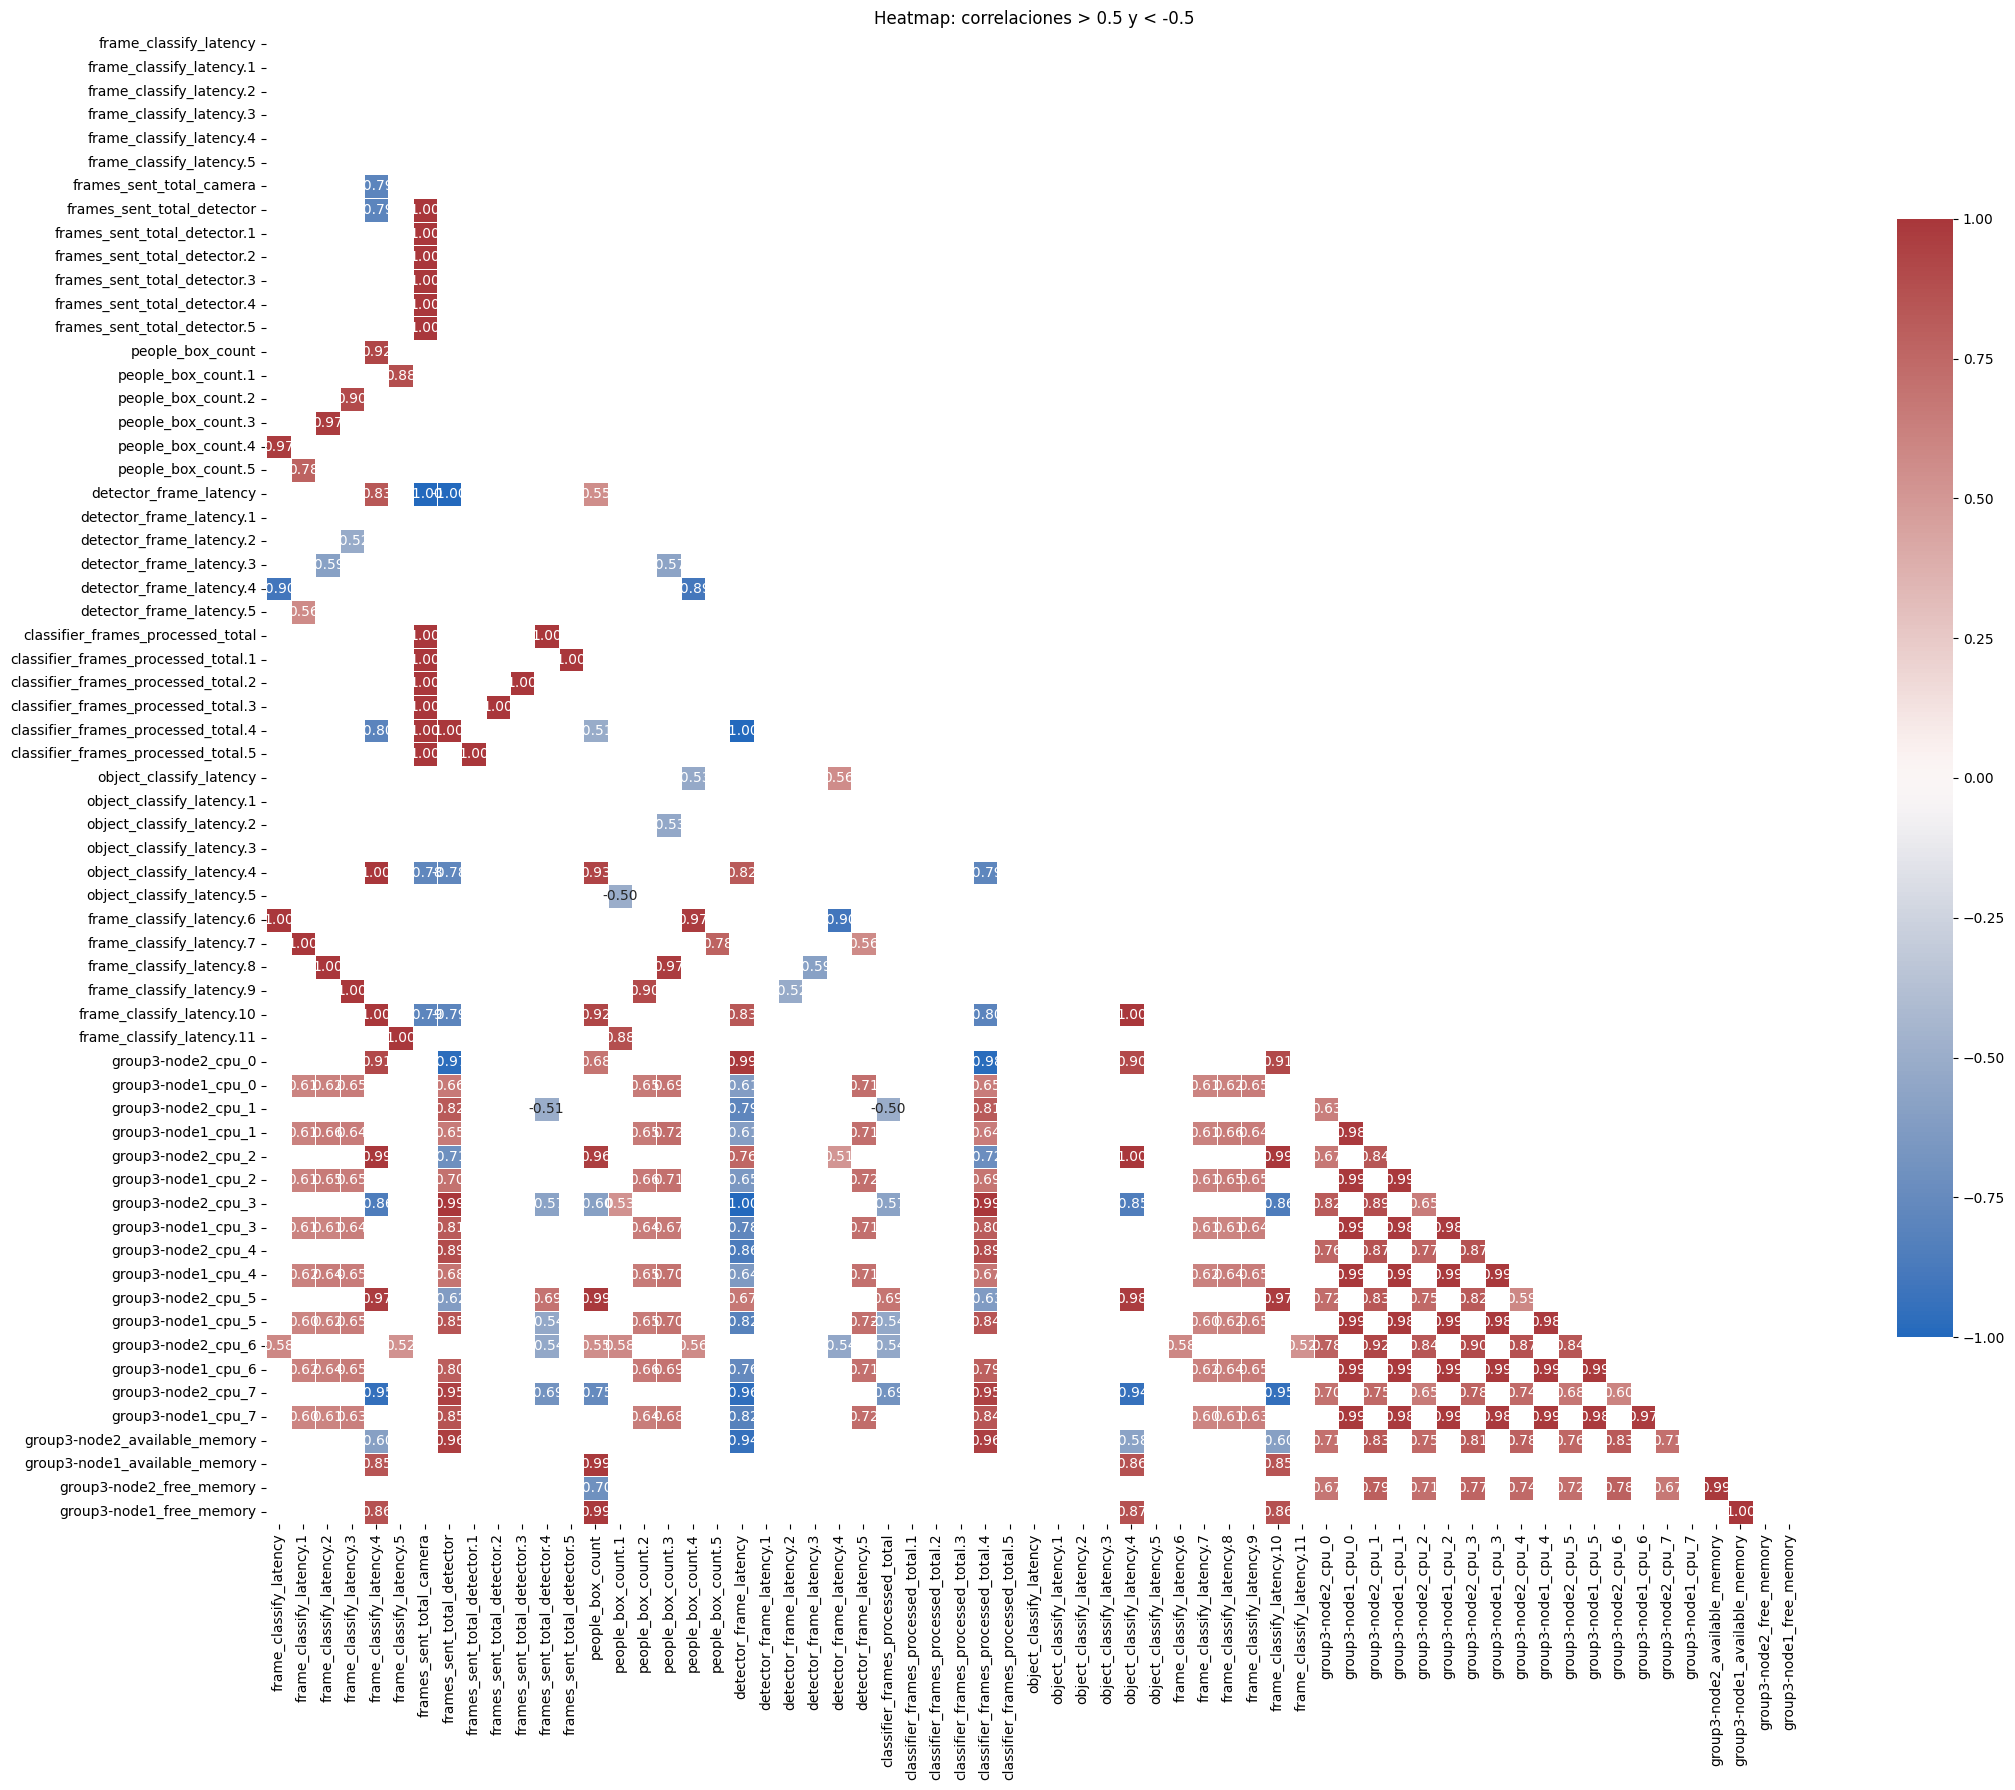

In [66]:
pos_thresh = 0.50   # mostrar correlaciones positivas > pos_thresh
neg_thresh = -0.50  # mostrar correlaciones negativas < neg_thresh

# validaciones simples
if not (-1.0 <= pos_thresh <= 1.0 and -1.0 <= neg_thresh <= 1.0):
    raise ValueError("Los umbrales deben estar entre -1 y 1")
if pos_thresh <= 0:
    raise ValueError("pos_thresh debe ser > 0 para filtrar correlaciones positivas")
if neg_thresh >= 0:
    raise ValueError("neg_thresh debe ser < 0 para filtrar correlaciones negativas")

# crear máscara que mantiene solo las correlaciones que cumplen las condiciones
cond = (corr > pos_thresh) | (corr < neg_thresh)
cond = cond.fillna(False)  # tratar NaNs como False


final_mask = np.triu(np.ones_like(corr, dtype=bool)) | (~cond.values)

n = len(cols_to_plot)
plt.figure(figsize=(min(24, n*0.35), min(18, n*0.35)))

sns.heatmap(corr, mask=final_mask, cmap='vlag', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": .75}, annot=True, fmt=".2f")

plt.title(f"Heatmap: correlaciones > {pos_thresh} y < {neg_thresh}")
plt.tight_layout()
plt.show()

In [67]:
# usar Time como eje temporal y plotear frames_sent_total_detector
df_plot = df.dropna(subset=['frames_sent_total_detector']).copy()
df_plot['timestamp'] = pd.to_datetime(df_plot['Time'], unit='ms')

plt.figure(figsize=(12, 4))
plt.plot(df_plot['timestamp'], df_plot['frames_sent_total_detector'], marker='o', linestyle='-')
plt.xlabel('Time')
plt.ylabel('frames_sent_total_detector')
plt.title('frames_sent_total_detector vs Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: ['frames_sent_total_detector']

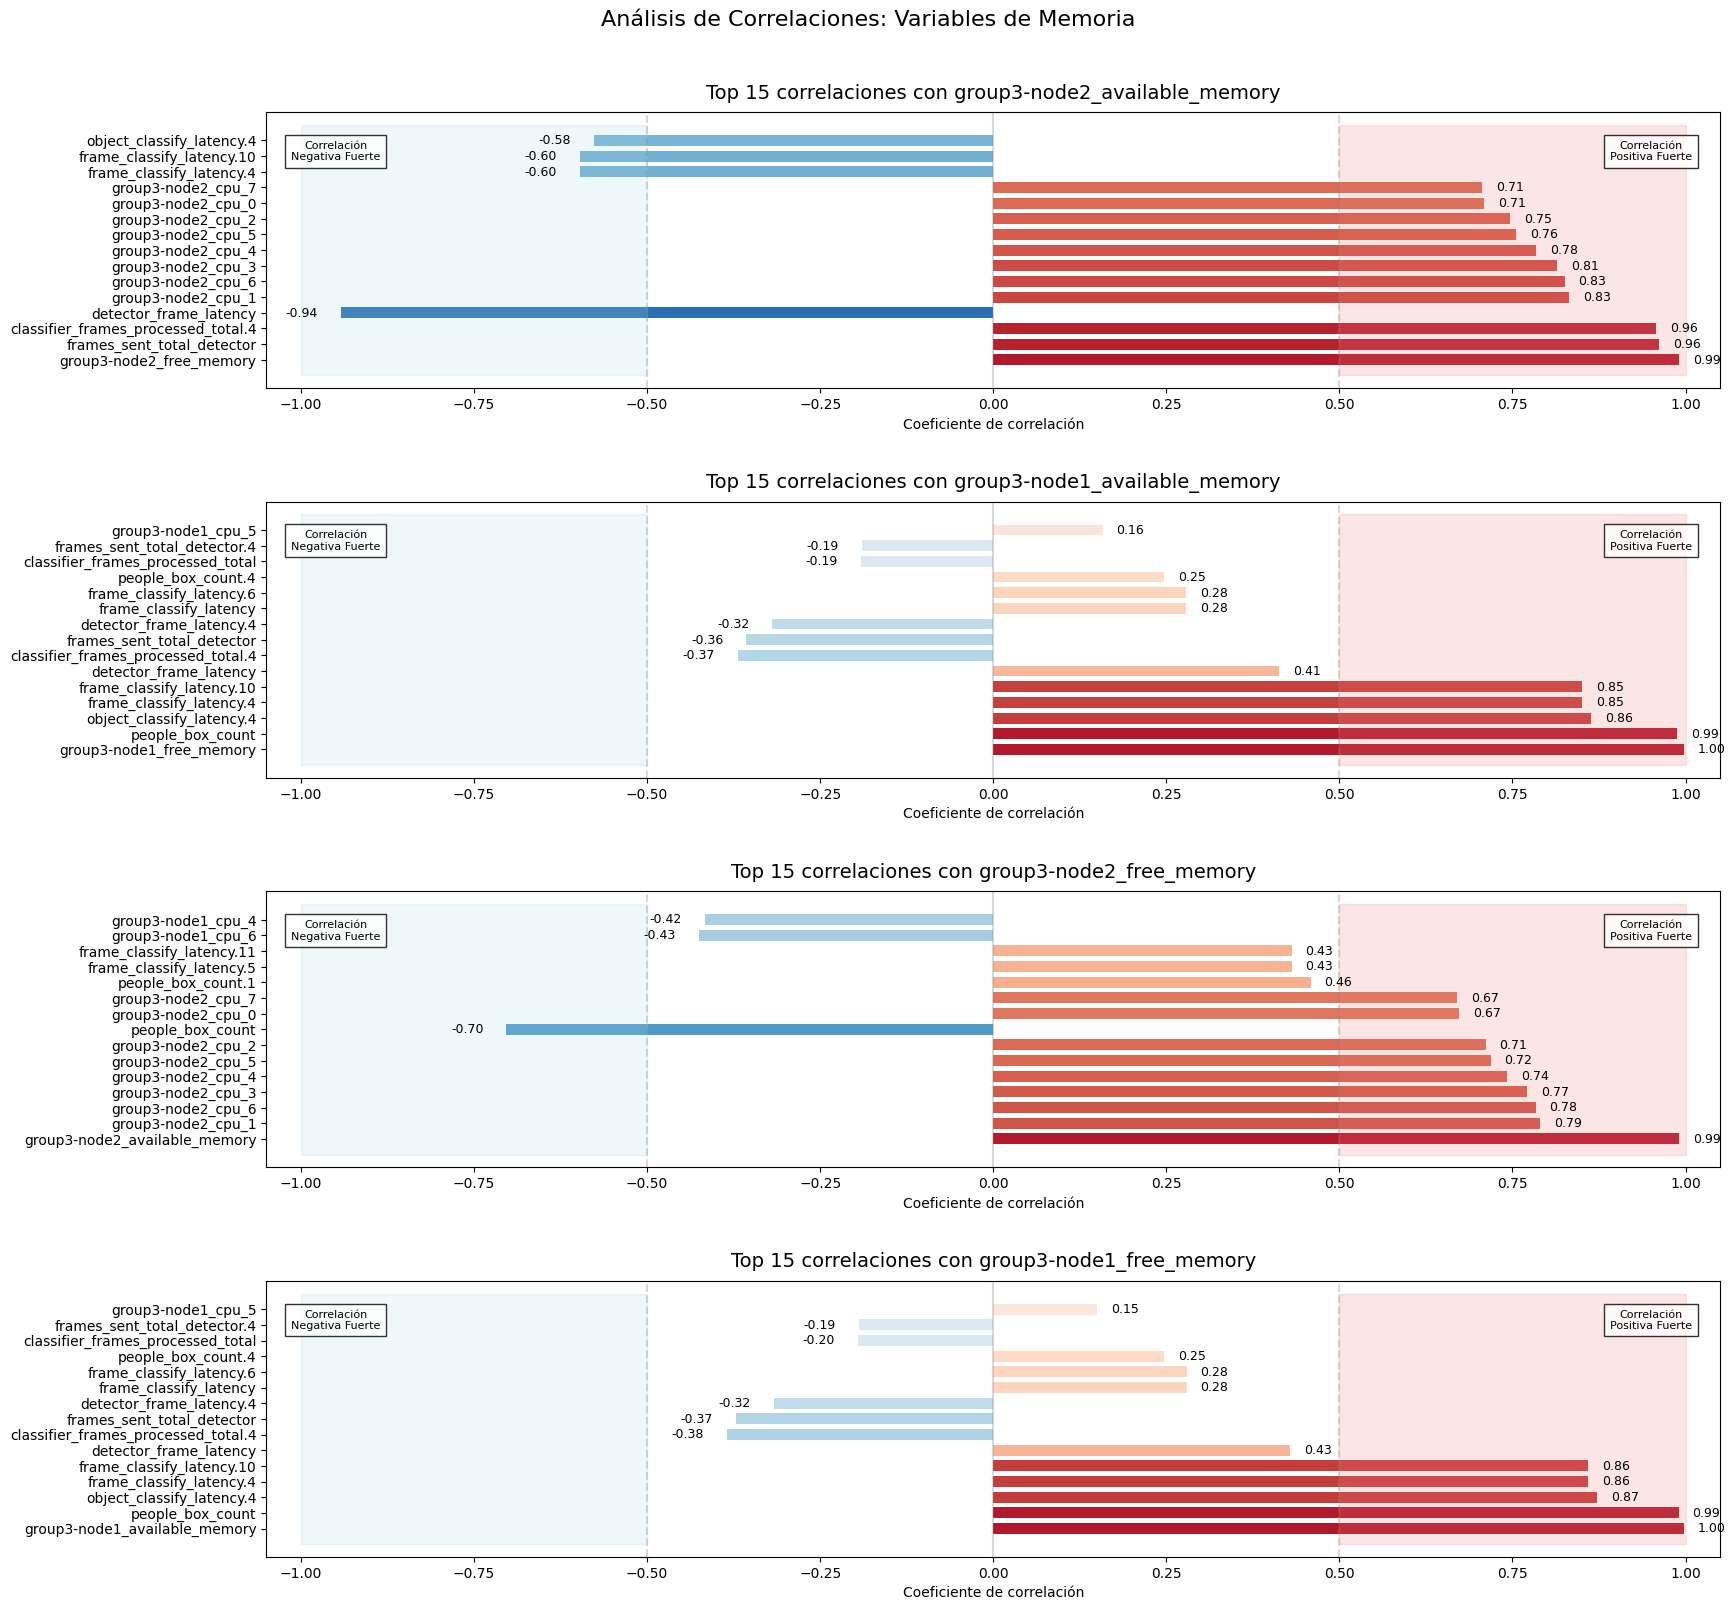

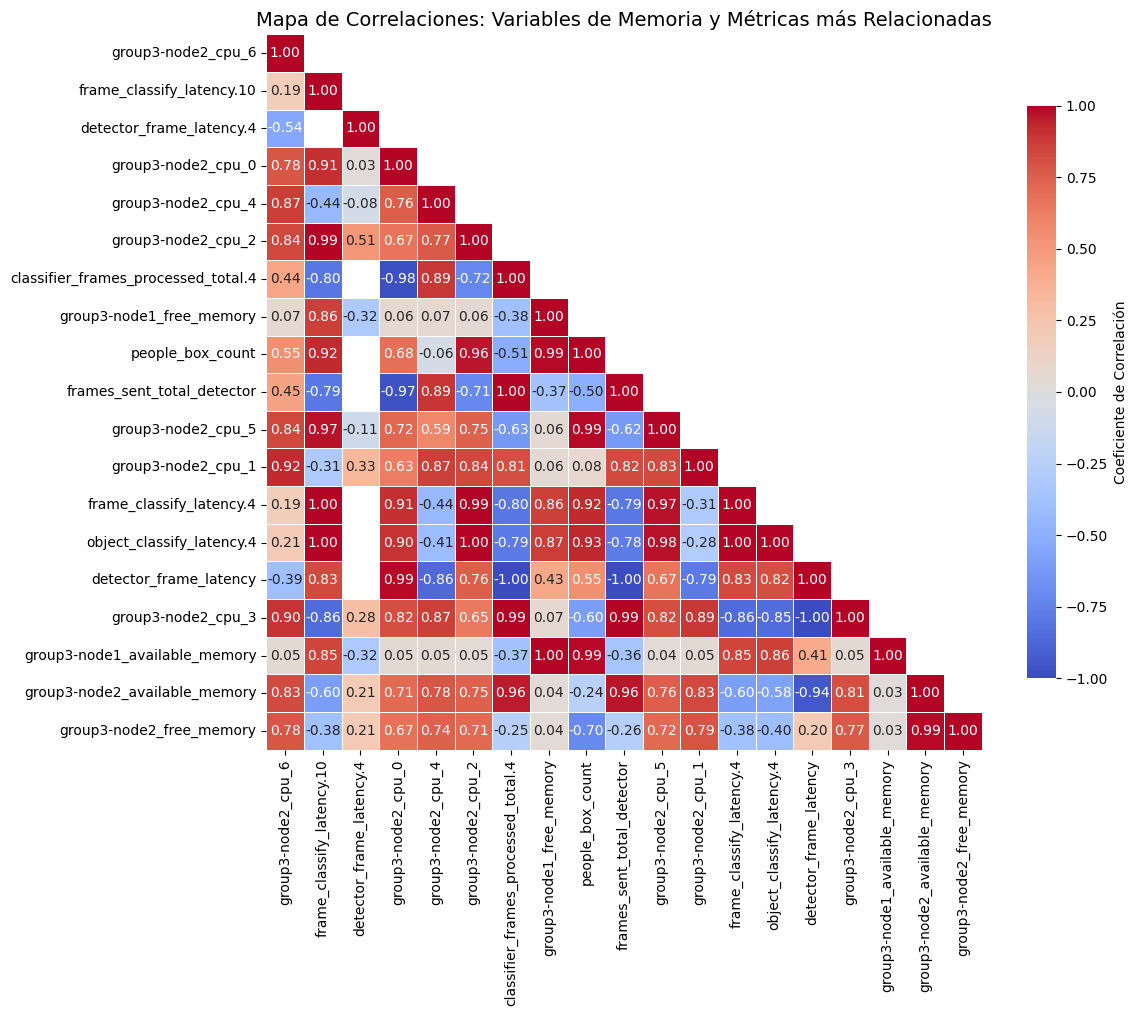

In [68]:
# Análisis mejorado de variables de memoria
mem_cols = [c for c in df_num.columns if 'memory' in c.lower()]

if mem_cols:
    # Crear figura con subplots
    fig = plt.figure(figsize=(18, 4 * len(mem_cols)))
    
    # Para cada variable de memoria, crear un subplot de barras horizontales
    for i, mem_var in enumerate(mem_cols):
        # Obtener correlaciones y eliminar autocorrelación
        correlations = corr[mem_var].drop(mem_var)
        
        # Seleccionar top 15 correlaciones por valor absoluto
        top_corr = correlations.abs().nlargest(15)
        top_corr_vars = top_corr.index
        
        # Crear el subplot
        ax = fig.add_subplot(len(mem_cols), 1, i+1)
        
        # Crear barra de correlaciones con colores según signo
        bars = ax.barh(
            y=range(len(top_corr_vars)),
            width=correlations[top_corr_vars],
            color=[plt.cm.RdBu_r(0.1 + 0.8 * (x + 1) / 2) for x in correlations[top_corr_vars]],
            height=0.7
        )
        
        # Añadir una línea vertical en x=0
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        
        # Añadir líneas de referencia
        ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.3)
        
        # Añadir etiquetas con valores numéricos
        for bar in bars:
            width = bar.get_width()
            label_x_pos = width + 0.02 if width > 0 else width - 0.08
            ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', va='center', fontsize=9)
        
        # Establecer límites del eje x
        ax.set_xlim(-1.05, 1.05)
        
        # Configurar etiquetas y títulos
        ax.set_yticks(range(len(top_corr_vars)))
        ax.set_yticklabels(top_corr_vars, fontsize=10)
        ax.set_xlabel('Coeficiente de correlación')
        ax.set_title(f'Top 15 correlaciones con {mem_var}', fontsize=14, pad=10)
        
        # Añadir zonas de correlación
        ax.fill_between([-1, -0.5], -1, len(top_corr_vars), color='lightblue', alpha=0.2)
        ax.fill_between([0.5, 1], -1, len(top_corr_vars), color='lightcoral', alpha=0.2)
        
        # Añadir textos explicativos
        ax.text(0.95, len(top_corr_vars)-1, "Correlación\nPositiva Fuerte", 
                ha='center', va='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.8))
        ax.text(-0.95, len(top_corr_vars)-1, "Correlación\nNegativa Fuerte", 
                ha='center', va='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.8))
    
    # Ajustar espaciado entre subplots
    plt.tight_layout(pad=3.0)
    
    # Añadir un título general
    fig.suptitle('Análisis de Correlaciones: Variables de Memoria', 
                fontsize=16, y=1.02)
    
    plt.show()
    
    # Crear un heatmap focalizado con las variables más correlacionadas
    # Obtener top variables que muestran fuertes correlaciones con cualquier variable de memoria
    top_corr_with_mem = set()
    for mem_var in mem_cols:
        corrs = corr[mem_var].abs().nlargest(10).index
        top_corr_with_mem.update(corrs)
    
    # Añadir las variables de memoria si no están ya
    top_corr_with_mem.update(mem_cols)
    
    # Crear dataframe con solo estas variables
    focused_corr = corr.loc[list(top_corr_with_mem), list(top_corr_with_mem)]
    
    # Crear heatmap mejorado
    plt.figure(figsize=(12, 10))
    mask = np.zeros_like(focused_corr)
    mask[np.triu_indices_from(mask, k=1)] = True  # Mostrar solo la mitad inferior
    
    sns.heatmap(focused_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
                annot=True, fmt='.2f', square=True, linewidths=.5,
                cbar_kws={"shrink": .8, "label": "Coeficiente de Correlación"})
    
    plt.title('Mapa de Correlaciones: Variables de Memoria y Métricas más Relacionadas', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas con 'memory' en el nombre.")

### Creando columnas ficticias

In [69]:
df_num['not_down'] = df_num['group3-node1_free_memory'].notna().astype(int)

df_num['not_down'].value_counts(dropna=False)

not_down
1    2582
0      13
Name: count, dtype: int64

In [ ]:
is_down = [0 if row == 1 else 1 for row in df_num['not_down']]
frame_latency = df_num['frame_clasframe_aggrupsify_latency'].to_list()

KeyError: 'frame_classify_latency'

In [56]:
df_num

,frame_classify_latency,frame_classify_latency.1,frame_classify_latency.2,frame_classify_latency.3,frame_classify_latency.4,frame_classify_latency.5,frames_sent_total_camera,frames_sent_total_detector,frames_sent_total_detector.1,frames_sent_total_detector.2,...,group3-node1_cpu_5,group3-node2_cpu_6,group3-node1_cpu_6,group3-node2_cpu_7,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down
0,NaN,NaN,NaN,151.955320,NaN,NaN,73967.0,NaN,NaN,73957.0,...,0.170865,0.002697,0.156685,0.003034,0.166611,11762.716409,6290.055870,10775.191686,4141.318636,1
1,NaN,NaN,NaN,131.305452,NaN,NaN,74057.0,NaN,NaN,74047.0,...,0.356754,0.003051,0.360003,0.002712,0.383946,9254.878708,14160.585358,8477.771319,9322.883315,1
2,NaN,NaN,NaN,127.154672,NaN,NaN,74147.0,NaN,NaN,74137.0,...,0.356949,0.002373,0.407627,0.001864,0.411695,4112.725569,14532.633276,3767.340042,9896.583753,1
3,NaN,NaN,NaN,142.214615,NaN,NaN,74237.0,NaN,NaN,74227.0,...,0.363898,0.001864,0.401695,0.001356,0.410000,2570.271915,13527.742254,2354.401947,9234.111229,1
4,NaN,NaN,NaN,122.834619,NaN,NaN,74327.0,NaN,NaN,74317.0,...,0.392542,0.002712,0.438305,0.001356,0.397966,3084.134600,15029.370299,2825.086666,9892.413599,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590,NaN,NaN,NaN,NaN,NaN,65.488323,37729.0,NaN,37719.0,NaN,...,0.182881,0.180169,0.206102,0.027797,0.217627,7114.029529,16178.274364,5493.189619,10656.452397,1
2591,NaN,NaN,NaN,NaN,NaN,116.020496,37819.0,NaN,37809.0,NaN,...,0.195593,0.279831,0.229322,0.037288,0.228644,8637.947497,16177.508872,6669.775887,10655.664791,1
2592,NaN,NaN,NaN,NaN,NaN,177.259133,37909.0,NaN,37899.0,NaN,...,0.230508,0.429322,0.227966,0.035424,0.231356,10669.598318,14155.208819,8238.319121,9323.572762,1
2593,NaN,NaN,NaN,NaN,NaN,190.736107,37999.0,NaN,37989.0,NaN,...,0.234915,0.463220,0.216271,0.057119,0.237797,10669.150887,14660.400821,8237.846266,9656.186308,1


In [53]:
down_component = 0
frame_latency = 0
total_cost = 0
for is_down, frame_latency in zip(is_down, frame_latency):
    down_component += 0.2 * is_down
    frame_latency += 0.4*frame_latency
total_cost = down_component + frame_latency
print(total_cost)

TypeError: 'int' object is not iterable

In [11]:
df_num.fillna(0, inplace=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df.loc[:, numeric_cols] = df.loc[:, numeric_cols].fillna(0)


c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning:

invalid value encountered in divide

c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning:

invalid value encountered in divide



Correlación de cada variable con 'not_down' (ordenadas):
not_down                               1.000000
classifier_frames_processed_total.3    0.637756
frames_sent_total_detector.2           0.636946
frames_sent_total_camera               0.130427
group3-node2_cpu_1                     0.029142
                                         ...   
group3-node1_cpu_5                          NaN
group3-node1_cpu_6                          NaN
group3-node1_cpu_7                          NaN
group3-node1_available_memory               NaN
group3-node1_free_memory                    NaN
Length: 64, dtype: float64

Top 10 correlaciones positivas con 'not_down':
not_down                               1.000000
classifier_frames_processed_total.3    0.637756
frames_sent_total_detector.2           0.636946
frames_sent_total_camera               0.130427
group3-node2_cpu_1                     0.029142
group3-node2_cpu_3                     0.028957
group3-node2_cpu_6                     0.028502
grou

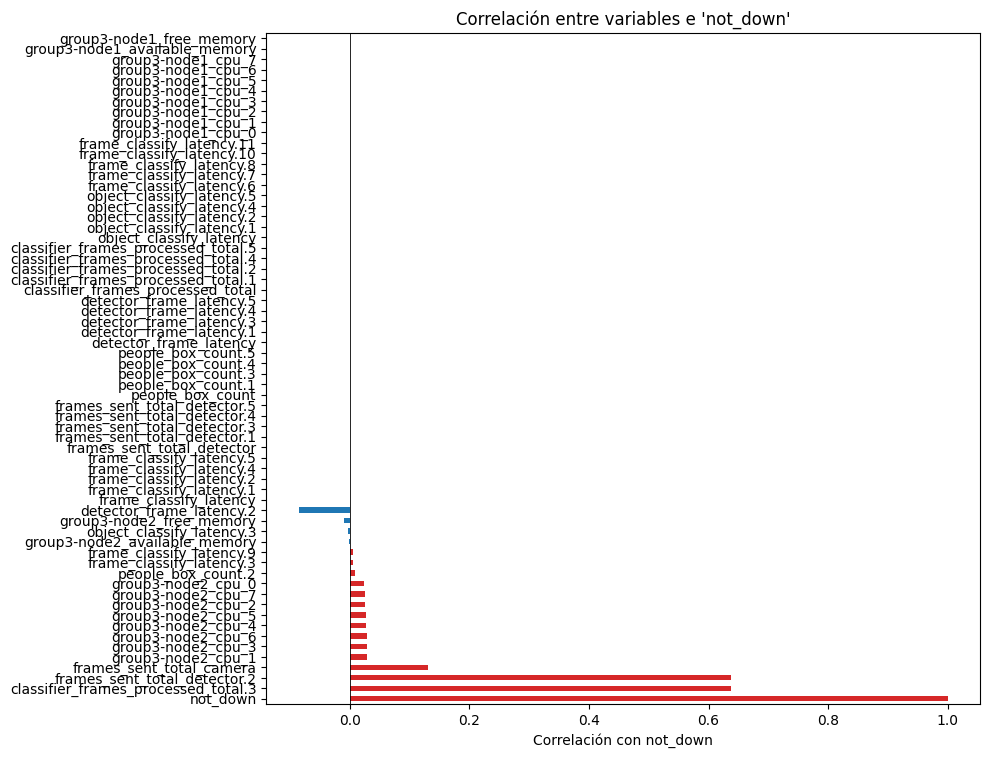

In [25]:
corr_with_is_down = df_num.corrwith(df_num['not_down']).sort_values(ascending=False)

print("Correlación de cada variable con 'not_down' (ordenadas):")
print(corr_with_is_down)

print("\nTop 10 correlaciones positivas con 'not_down':")
print(corr_with_is_down.head(10))

print("\nTop 10 correlaciones negativas con 'not_down':")
print(corr_with_is_down.tail(10))

plt.figure(figsize=(10, max(4, len(corr_with_is_down) * 0.12)))
colors = ['tab:red' if v > 0 else 'tab:blue' for v in corr_with_is_down.values]
corr_with_is_down.plot(kind='barh', color=colors)
plt.xlabel('Correlación con not_down')
plt.title("Correlación entre variables e 'not_down'")
plt.axvline(0, color='k', linewidth=0.6)
plt.tight_layout()
plt.show()

In [26]:
df_num

,frame_classify_latency,frame_classify_latency.1,frame_classify_latency.2,frame_classify_latency.3,frame_classify_latency.4,frame_classify_latency.5,frames_sent_total_camera,frames_sent_total_detector,frames_sent_total_detector.1,frames_sent_total_detector.2,...,group3-node1_cpu_5,group3-node2_cpu_6,group3-node1_cpu_6,group3-node2_cpu_7,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down
0,NaN,NaN,NaN,150.861822,NaN,NaN,48227.0,NaN,NaN,48217.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,153.651723,NaN,NaN,48317.0,NaN,NaN,48307.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,NaN,NaN,NaN,104.166308,NaN,NaN,48407.0,NaN,NaN,48397.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NaN,NaN,NaN,173.210130,NaN,NaN,48497.0,NaN,NaN,48487.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,94.773159,NaN,NaN,48587.0,NaN,NaN,48577.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2876,NaN,NaN,NaN,NaN,NaN,65.488323,37729.0,NaN,37719.0,NaN,...,0.182881,0.180169,0.206102,0.027797,0.217627,7114.029529,16178.274364,5493.189619,10656.452397,1
2877,NaN,NaN,NaN,NaN,NaN,116.020496,37819.0,NaN,37809.0,NaN,...,0.195593,0.279831,0.229322,0.037288,0.228644,8637.947497,16177.508872,6669.775887,10655.664791,1
2878,NaN,NaN,NaN,NaN,NaN,177.259133,37909.0,NaN,37899.0,NaN,...,0.230508,0.429322,0.227966,0.035424,0.231356,10669.598318,14155.208819,8238.319121,9323.572762,1
2879,NaN,NaN,NaN,NaN,NaN,190.736107,37999.0,NaN,37989.0,NaN,...,0.234915,0.463220,0.216271,0.057119,0.237797,10669.150887,14660.400821,8237.846266,9656.186308,1


### XGBoost

In [16]:
import pandas as pd

# Creamos target desplazado: "en el próximo minuto estará apagado"
df_num['target'] = df_num['not_down'].shift(-4)

# Eliminamos el último registro porque ya no tiene target válido
df_num = df_num.dropna(subset=['target'])

# Features = todas las columnas menos 'not_down' y 'target'
X = df_num.drop(columns=['not_down', 'target'])
y = df_num['target']


from sklearn.model_selection import train_test_split

# Usamos 80% primeros registros para train, 20% últimos para test
train_size = int(0.8 * len(df_num))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Modelo
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])  # balance clases
)

# Entrenamiento
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluación
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))



              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.97      0.98       517

    accuracy                           0.97       517
   macro avg       0.50      0.48      0.49       517
weighted avg       1.00      0.97      0.98       517

ROC-AUC: nan


c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\h

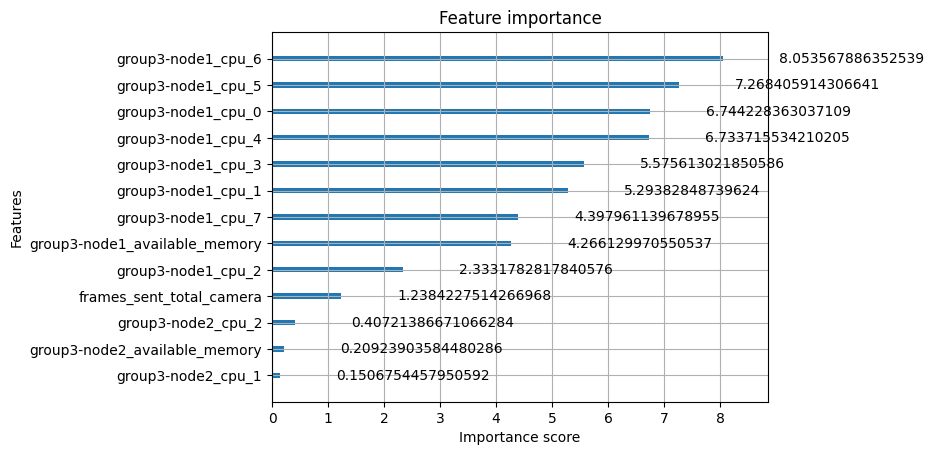

In [14]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()


### LAGED XGBOOST

In [14]:
import pandas as pd
df_num['target'] = df_num['not_down'].shift(-1)

def create_lag_features(df, cols, n_lags=1, rolling_windows=[3,5]):
    df_new = df.copy()
    for col in cols:
        for lag in range(1, n_lags+1):
            df_new[f"{col}_lag{lag}"] = df_new[col].shift(lag)
        for w in rolling_windows:
            df_new[f"{col}_rollmean{w}"] = df_new[col].rolling(w).mean()
            df_new[f"{col}_rollstd{w}"] = df_new[col].rolling(w).std()
    return df_new

# Excluimos las columnas que no deben tener lags
feature_cols = [c for c in df_num.columns if c not in ['not_down', 'target']]
df_feat = create_lag_features(df_num, feature_cols, n_lags=2, rolling_windows=[2,4])

# Eliminamos los primeros registros con NaN generados por lags
df_feat = df_feat.dropna()


C:\Users\halol\AppData\Local\Temp\ipykernel_7356\785085801.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[f"{col}_rollmean{w}"] = df_new[col].rolling(w).mean()
C:\Users\halol\AppData\Local\Temp\ipykernel_7356\785085801.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[f"{col}_rollstd{w}"] = df_new[col].rolling(w).std()
C:\Users\halol\AppData\Local\Temp\ipykernel_7356\785085801.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

In [15]:
df_feat

,frame_classify_latency,frame_classify_latency.1,frame_classify_latency.2,frame_classify_latency.3,frame_classify_latency.4,frame_classify_latency.5,frames_sent_total_camera,frames_sent_total_detector,frames_sent_total_detector.1,frames_sent_total_detector.2,...,group3-node2_free_memory_rollmean2,group3-node2_free_memory_rollstd2,group3-node2_free_memory_rollmean4,group3-node2_free_memory_rollstd4,group3-node1_free_memory_lag1,group3-node1_free_memory_lag2,group3-node1_free_memory_rollmean2,group3-node1_free_memory_rollstd2,group3-node1_free_memory_rollmean4,group3-node1_free_memory_rollstd4
3,0.0,0.0,0.0,142.214615,0.0,0.000000,74237.0,0.0,0.0,74227.0,...,3060.870994,999.098109,6343.676248,3947.341238,9896.583753,9322.883315,9565.347491,468.438814,8148.724233,2687.689652
4,0.0,0.0,0.0,122.834619,0.0,0.000000,74327.0,0.0,0.0,74317.0,...,2589.744306,332.824357,4356.149993,2809.840426,9234.111229,9896.583753,9563.262414,465.490070,9586.497974,357.494366
5,0.0,0.0,0.0,154.246857,0.0,0.000000,74417.0,0.0,0.0,74407.0,...,3531.224974,998.630372,3296.047984,859.591476,9892.413599,9234.111229,10386.824318,699.202344,9976.085904,679.004914
6,0.0,0.0,0.0,72.596277,0.0,0.000000,74507.0,0.0,0.0,74497.0,...,4943.325708,998.381639,3766.535007,1488.498501,10881.235037,9892.413599,10880.824649,0.580376,10222.043532,806.773736
7,0.0,0.0,0.0,96.320369,0.0,0.000000,74597.0,0.0,0.0,74587.0,...,5649.080740,0.293301,4590.152857,1351.859923,10880.414261,10881.235037,10715.999437,232.517674,10551.411878,465.941572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2589,0.0,0.0,0.0,0.000000,0.0,37.698310,37639.0,0.0,37629.0,0.0,...,6081.655422,277.403880,5885.516453,320.382282,9324.267015,9657.311904,9657.197729,470.835131,9573.930747,318.832499
2590,0.0,0.0,0.0,0.000000,0.0,65.488323,37729.0,0.0,37719.0,0.0,...,5689.345438,277.406220,5787.384253,375.648333,9990.128443,9324.267015,10323.290420,471.162186,9907.039940,568.773858
2591,0.0,0.0,0.0,0.000000,0.0,116.020496,37819.0,0.0,37809.0,0.0,...,6081.482753,831.972129,6081.569088,506.336702,10656.452397,9990.128443,10656.058594,0.556922,10156.628161,637.549752
2592,0.0,0.0,0.0,0.000000,0.0,177.259133,37909.0,0.0,37899.0,0.0,...,7454.047504,1109.127557,6571.696471,1213.986756,10655.664791,10656.452397,9989.618776,941.931307,10156.454598,637.851905


In [16]:
X = df_feat.drop(columns=['not_down', 'target'])
y = df_feat['target']
train_size = int(0.8 * len(df_feat))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])  # balance clases
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.98      0.99       519

    accuracy                           0.98       519
   macro avg       0.50      0.49      0.50       519
weighted avg       1.00      0.98      0.99       519

ROC-AUC: nan


c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\h

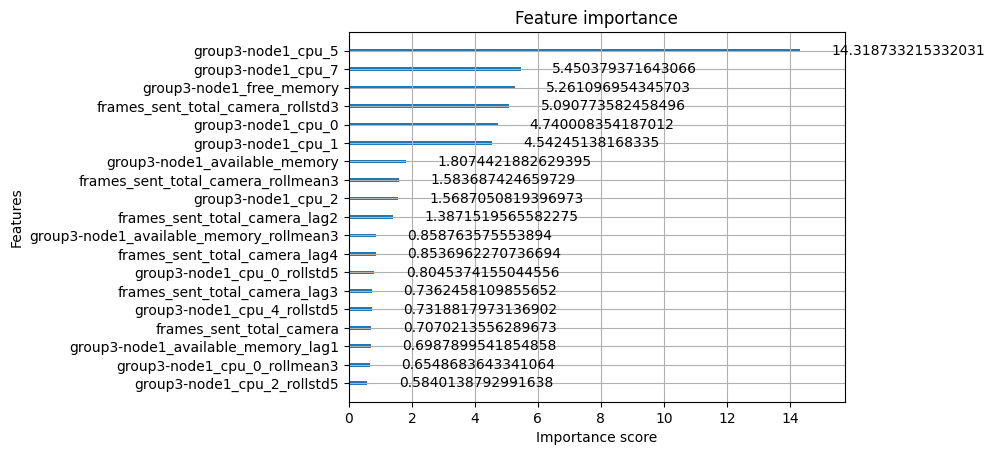

In [15]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()


Distribution of 'not_down':
not_down
1    2581
0      13
Name: count, dtype: int64
Percentage of class 1: 99.50%

Model Evaluation:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      1.00      1.00         3
    Not Down       1.00      1.00      1.00       516

    accuracy                           1.00       519
   macro avg       1.00      1.00      1.00       519
weighted avg       1.00      1.00      1.00       519



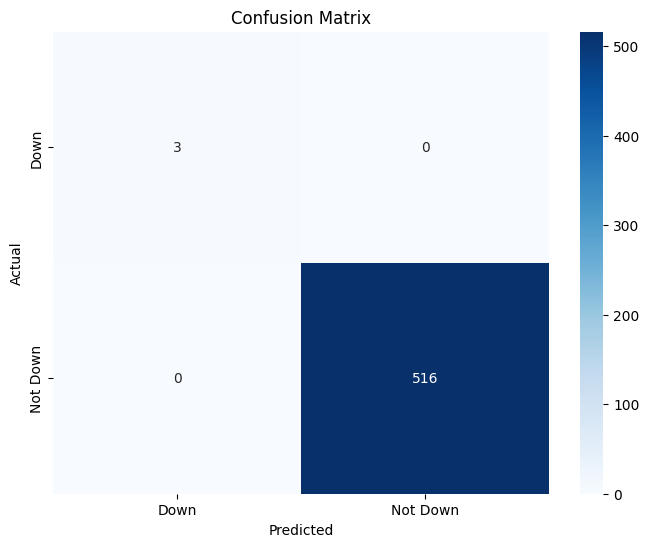

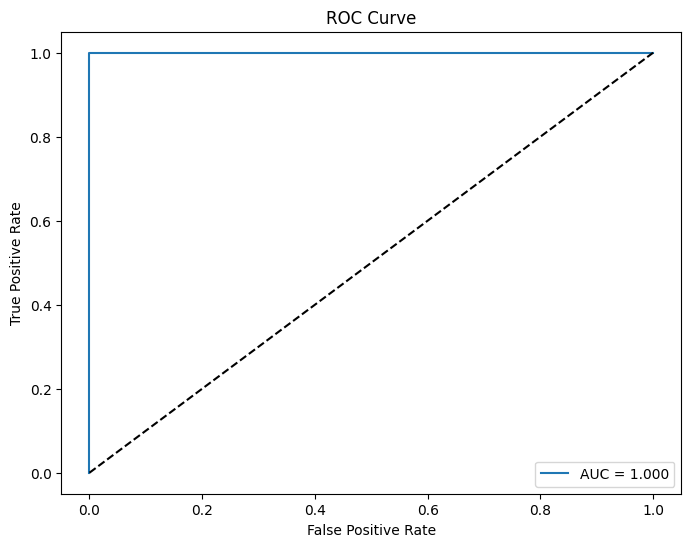

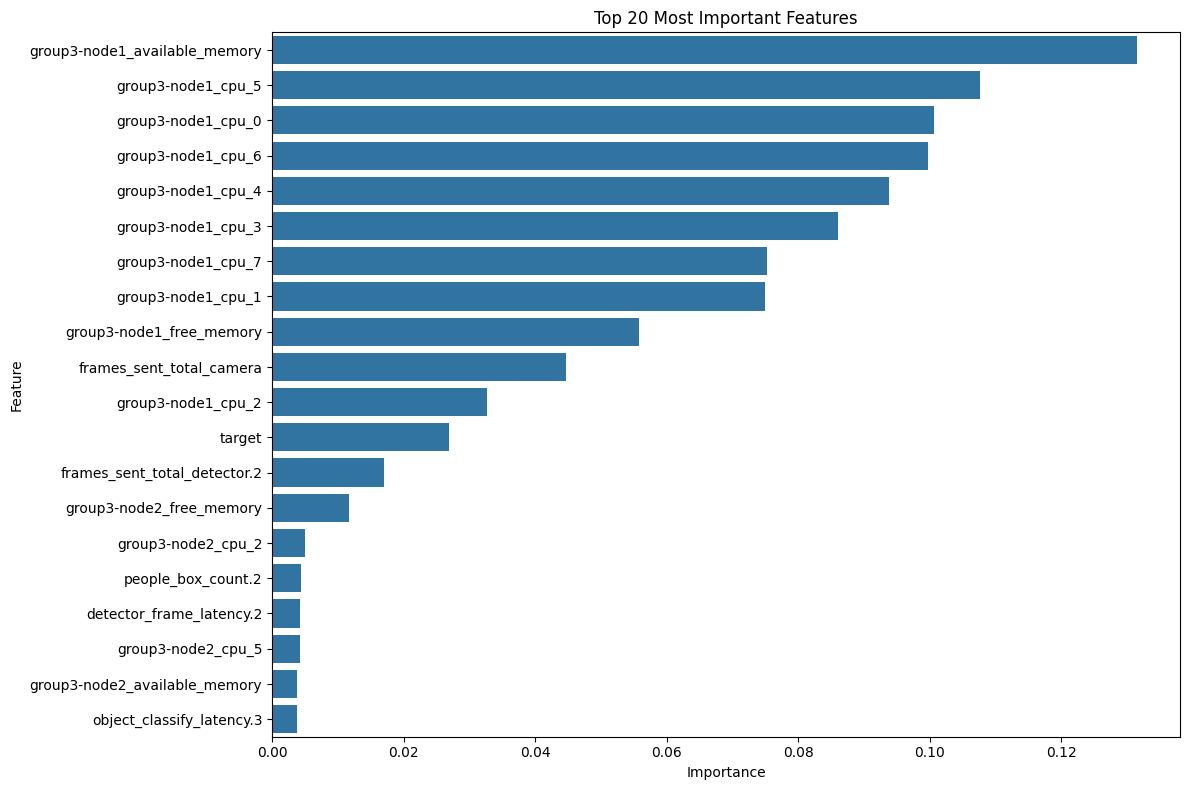


Top 15 most important features:
                          Feature  Importance
0   group3-node1_available_memory    0.131451
1              group3-node1_cpu_5    0.107669
2              group3-node1_cpu_0    0.100644
3              group3-node1_cpu_6    0.099784
4              group3-node1_cpu_4    0.093833
5              group3-node1_cpu_3    0.085990
6              group3-node1_cpu_7    0.075279
7              group3-node1_cpu_1    0.075012
8        group3-node1_free_memory    0.055802
9        frames_sent_total_camera    0.044720
10             group3-node1_cpu_2    0.032750
11                         target    0.026969
12   frames_sent_total_detector.2    0.017080
13       group3-node2_free_memory    0.011761
14             group3-node2_cpu_2    0.004996

Identified 14 important features (>1% importance):
['group3-node1_available_memory', 'group3-node1_cpu_5', 'group3-node1_cpu_0', 'group3-node1_cpu_6', 'group3-node1_cpu_4', 'group3-node1_cpu_3', 'group3-node1_cpu_7', 'group3-node1

In [15]:
# Check target variable distribution
print("Distribution of 'not_down':")
print(df_num['not_down'].value_counts())
print(f"Percentage of class 1: {df_num['not_down'].mean() * 100:.2f}%")

# Split data into features and target
X = df_num.drop('not_down', axis=1)
y = df_num['not_down']

# Train-test split (using stratified sampling to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# map class numeric labels to readable names (0 -> Down, 1 -> Not Down)
labels_order = list(rf_model.classes_)
label_name_map = {0: 'Down', 1: 'Not Down'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in labels_order]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot confusion matrix with correct class names
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Feature importance
feature_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20))
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# Print the top 15 features
print("\nTop 15 most important features:")
print(feature_imp.head(15))

# Identify the most important features (those with importance > 1%)
important_features = feature_imp[feature_imp['Importance'] > 0.01]['Feature'].tolist()
print(f"\nIdentified {len(important_features)} important features (>1% importance):")
print(important_features)

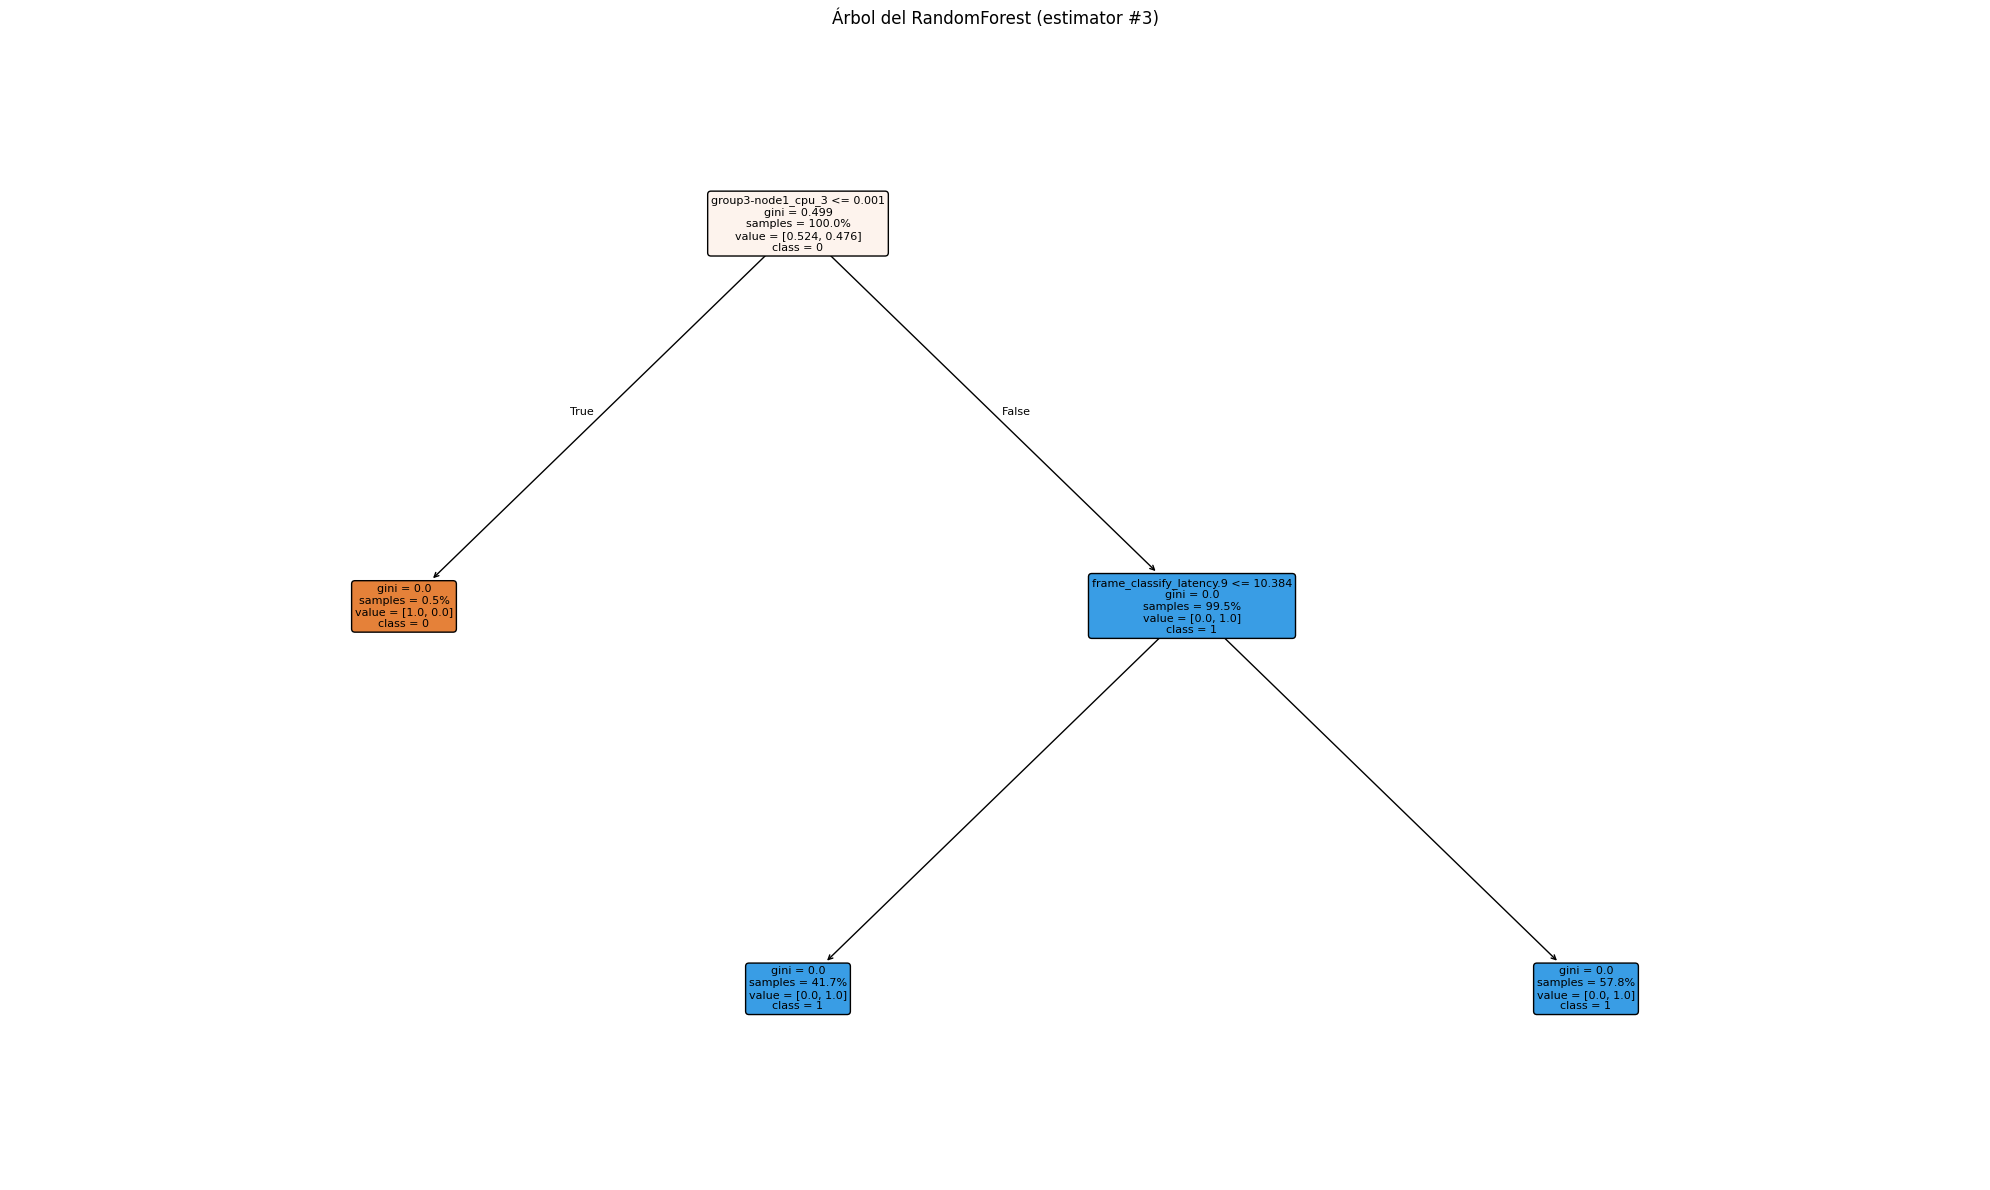

In [221]:
from sklearn import tree

import matplotlib.pyplot as plt

# elegir índice del árbol (usa la variable `i` si existe, sino 0)
try:
    est_idx = int(i)
except NameError:
    est_idx = 0
except Exception:
    est_idx = 0

if not hasattr(rf_model, "estimators_"):
    raise ValueError("rf_model no contiene estimors_. Entrena el modelo antes de mostrar un árbol.")

if est_idx < 0 or est_idx >= len(rf_model.estimators_):
    raise IndexError(f"est_idx {est_idx} fuera de rango (0..{len(rf_model.estimators_)-1})")

est = rf_model.estimators_[est_idx]

plt.figure(figsize=(20, 12))
tree.plot_tree(
    est,
    feature_names=X_train.columns if 'X_train' in globals() else None,
    class_names=[str(c) for c in rf_model.classes_],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=8
)
plt.title(f"Árbol del RandomForest (estimator #{est_idx})")
plt.tight_layout()
plt.show()

### LAG MODEL 1 period

In [34]:
# 1. Asegurar que los datos estén ordenados cronológicamente
df_sorted = df.sort_values('Time').reset_index(drop=True)
df_num_sorted = df_num.sort_values('Time') if 'Time' in df_num.columns else df_num

# 2. Crear la nueva variable objetivo con lag (shift negativo)
# Por ejemplo, para predecir el estado 4 puntos de tiempo antes:
lag_steps = 1  # Ajusta este valor según el lag temporal deseado
df_num_sorted['future_down'] = df_num_sorted['not_down'].shift(-lag_steps)

# 3. Eliminar las filas donde no tenemos el valor futuro (al final del dataset)
df_num_sorted.dropna(subset=['future_down'], inplace=True)

# 4. Preparar datos para entrenamiento
X = df_num_sorted.drop(['not_down', 'future_down'], axis=1)  # Usar datos actuales
y = df_num_sorted['future_down']  # Predecir estado futuro

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=None, random_state=42, stratify=y
)

# 6. Entrenar modelo con la nueva variable objetivo
rf_model_predictive = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

rf_model_predictive.fit(X_train, y_train)

# 7. Evaluar el modelo predictivo
y_pred = rf_model_predictive.predict(X_test)
print(f"Accuracy (modelo predictivo con lag {lag_steps}): {accuracy_score(y_test, y_pred):.4f}")

# 8. Mostrar informe de clasificación
label_name_map = {0: f'Down en {lag_steps} unidades', 1: f'Operativo en {lag_steps} unidades'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in rf_model_predictive.classes_]
print("\nInforme de clasificación (modelo predictivo):")
print(classification_report(y_test, y_pred, target_names=target_names))

# 9. Analizar características importantes para la predicción anticipada
feature_imp = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model_predictive.feature_importances_
})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 15 características para predicción anticipada:")
print(feature_imp.head(15))

Accuracy (modelo predictivo con lag 1): 0.9944

Informe de clasificación (modelo predictivo):
                         precision    recall  f1-score   support

     Down en 1 unidades       0.97      0.97      0.97        75
Operativo en 1 unidades       1.00      1.00      1.00       642

               accuracy                           0.99       717
              macro avg       0.99      0.99      0.99       717
           weighted avg       0.99      0.99      0.99       717


Top 15 características para predicción anticipada:
                                Feature  Importance
0                    group3-node1_cpu_2    0.110451
1                    group3-node1_cpu_5    0.100866
2                    group3-node1_cpu_4    0.091490
3                    group3-node1_cpu_0    0.085489
4   classifier_frames_processed_total.3    0.075495
5         group3-node1_available_memory    0.072602
6                    group3-node1_cpu_3    0.072179
7                    group3-node1_cpu_1    0.


Evaluación del Modelo Predictivo (Lag):
Accuracy: 0.9944

Informe de clasificación (modelo predictivo):
                         precision    recall  f1-score   support

     Down en 1 unidades       0.97      0.97      0.97        75
Operativo en 1 unidades       1.00      1.00      1.00       642

               accuracy                           0.99       717
              macro avg       0.99      0.99      0.99       717
           weighted avg       0.99      0.99      0.99       717



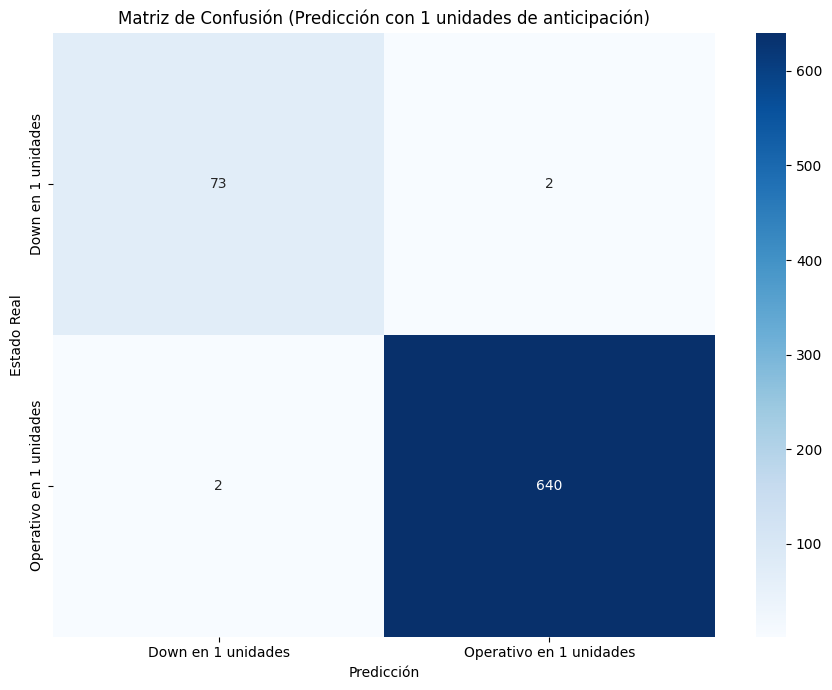

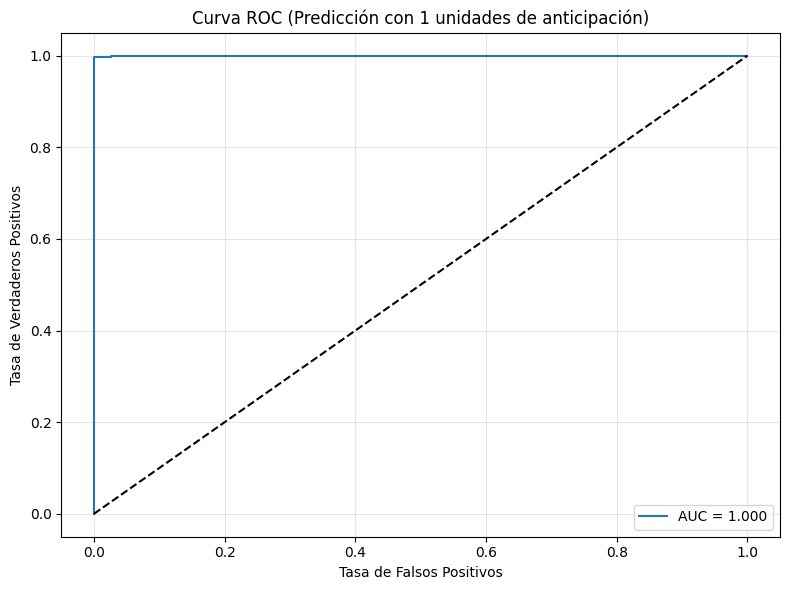

C:\Users\halol\AppData\Local\Temp\ipykernel_6684\3290682894.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




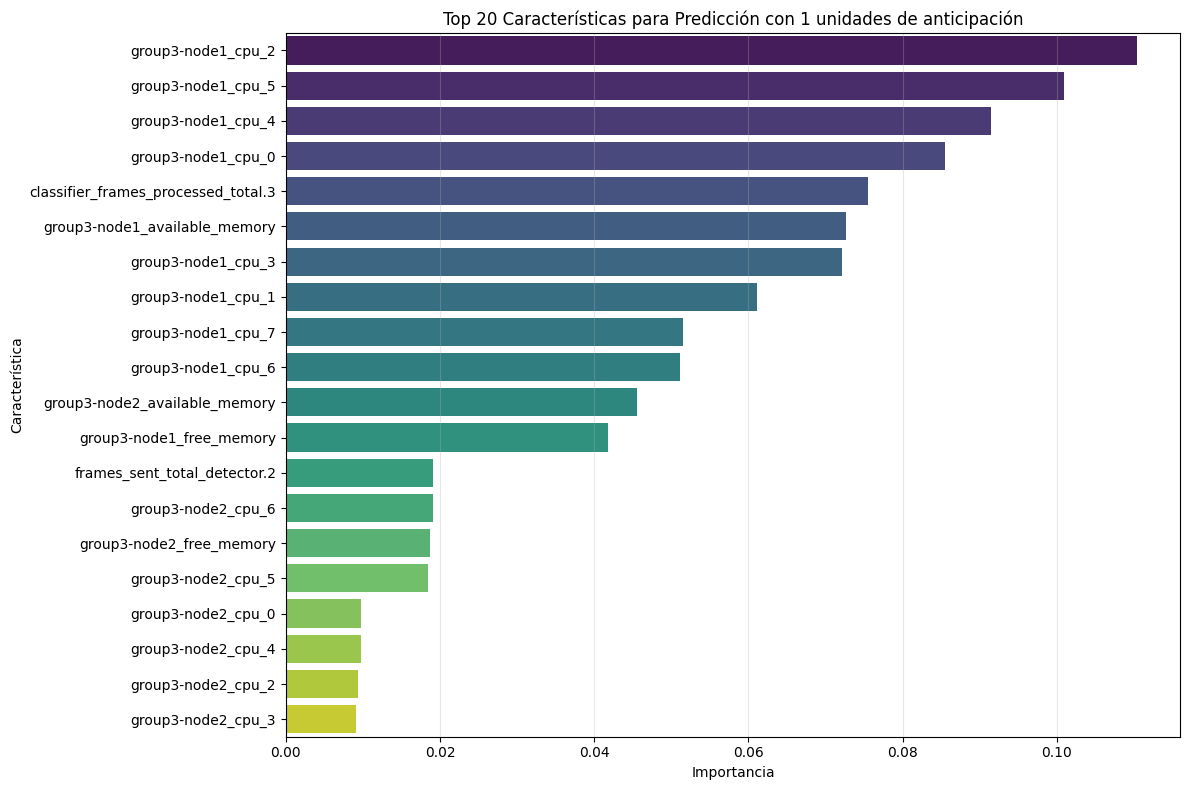


Top 15 características para predicción con 1 unidades de anticipación:
                                Feature  Importance
0                    group3-node1_cpu_2    0.110451
1                    group3-node1_cpu_5    0.100866
2                    group3-node1_cpu_4    0.091490
3                    group3-node1_cpu_0    0.085489
4   classifier_frames_processed_total.3    0.075495
5         group3-node1_available_memory    0.072602
6                    group3-node1_cpu_3    0.072179
7                    group3-node1_cpu_1    0.061075
8                    group3-node1_cpu_7    0.051556
9                    group3-node1_cpu_6    0.051104
10        group3-node2_available_memory    0.045506
11             group3-node1_free_memory    0.041778
12         frames_sent_total_detector.2    0.019131
13                   group3-node2_cpu_6    0.019107
14             group3-node2_free_memory    0.018737

Identificadas 16 características importantes (>1% importancia):
['group3-node1_cpu_2', 'group3-

In [35]:
# Crear probabilidades de predicción (necesarias para ROC)
y_pred = rf_model_predictive.predict(X_test)
y_prob = rf_model_predictive.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

# Evaluación del modelo
print("\nEvaluación del Modelo Predictivo (Lag):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Definir etiquetas con información de lag
labels_order = list(rf_model_predictive.classes_)
label_name_map = {0: f'Down en {lag_steps} unidades', 1: f'Operativo en {lag_steps} unidades'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in labels_order]

# Reporte de clasificación
print("\nInforme de clasificación (modelo predictivo):")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicción')
plt.ylabel('Estado Real')
plt.title(f'Matriz de Confusión (Predicción con {lag_steps} unidades de anticipación)')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC (Predicción con {lag_steps} unidades de anticipación)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Importancia de características
feature_imp = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model_predictive.feature_importances_
})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Visualizar top 20 características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')
plt.title(f'Top 20 Características para Predicción con {lag_steps} unidades de anticipación')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar top 15 características en texto
print(f"\nTop 15 características para predicción con {lag_steps} unidades de anticipación:")
print(feature_imp.head(15))

# Identificar características importantes (>1%)
important_features = feature_imp[feature_imp['Importance'] > 0.01]['Feature'].tolist()
print(f"\nIdentificadas {len(important_features)} características importantes (>1% importancia):")
print(important_features)

# ADICIONAL: Visualización de predicciones vs. valores reales en la serie temporal
if 'Time' in df_num_sorted.columns:
    # Crear predicciones para todo el conjunto
    all_X = df_num_sorted.drop(['not_down', 'future_down'], axis=1)
    all_predictions = rf_model_predictive.predict(all_X)
    
    # Dataframe para visualización
    df_vis = pd.DataFrame({
        'Time': pd.to_datetime(df_num_sorted['Time'], unit='ms') if not pd.api.types.is_datetime64_any_dtype(df_num_sorted['Time']) else df_num_sorted['Time'],
        'Real': df_num_sorted['future_down'],
        'Predicción': all_predictions
    })
    
    plt.figure(figsize=(14, 6))
    
    # Índices donde hay errores
    errores = df_vis['Real'] != df_vis['Predicción']
    aciertos = ~errores
    
    # Graficar puntos acertados y errores con colores distintos
    plt.scatter(df_vis.loc[aciertos, 'Time'], df_vis.loc[aciertos, 'Real'], 
                c='green', label='Aciertos', alpha=0.6, s=30, marker='o')
    plt.scatter(df_vis.loc[errores, 'Time'], df_vis.loc[errores, 'Real'], 
                c='red', label='Errores de predicción', alpha=0.8, s=50, marker='x')
    
    plt.yticks([0, 1], [label_name_map[0], label_name_map[1]])
    plt.title(f'Predicciones vs. Estado Real (Lag={lag_steps})')
    plt.xlabel('Tiempo')
    plt.ylabel('Estado del Sistema')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Mostrar tasa de acierto global
    print(f"Tasa de acierto global: {(~errores).mean()*100:.2f}%")

In [204]:
X

,frame_classify_latency,frame_classify_latency.1,frame_classify_latency.2,frame_classify_latency.3,frame_classify_latency.4,frame_classify_latency.5,frames_sent_total_camera,frames_sent_total_detector,frames_sent_total_detector.1,frames_sent_total_detector.2,...,group3-node2_cpu_6,group3-node1_cpu_6,group3-node2_cpu_7,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,future_down
0,0.0,0.0,0.0,151.955320,0.0,0.0,73967.0,0.0,0.0,73957.0,...,0.002697,0.156685,0.003034,0.166611,11762.716409,6290.055870,10775.191686,4141.318636,1,1.0
1,0.0,0.0,0.0,131.305452,0.0,0.0,74057.0,0.0,0.0,74047.0,...,0.003051,0.360003,0.002712,0.383946,9254.878708,14160.585358,8477.771319,9322.883315,1,1.0
2,0.0,0.0,0.0,127.154672,0.0,0.0,74147.0,0.0,0.0,74137.0,...,0.002373,0.407627,0.001864,0.411695,4112.725569,14532.633276,3767.340042,9896.583753,1,1.0
3,0.0,0.0,0.0,142.214615,0.0,0.0,74237.0,0.0,0.0,74227.0,...,0.001864,0.401695,0.001356,0.410000,2570.271915,13527.742254,2354.401947,9234.111229,1,1.0
4,0.0,0.0,0.0,122.834619,0.0,0.0,74327.0,0.0,0.0,74317.0,...,0.002712,0.438305,0.001356,0.397966,3084.134600,15029.370299,2825.086666,9892.413599,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003898,0.005254,0.003220,0.003729,2050.925516,6139.108316,1711.883011,3734.280787,1,1.0
2159,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002712,0.005763,0.001695,0.003051,0.005297,4095.381157,0.004635,2379.219876,1,1.0
2160,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002034,0.005254,0.001525,0.002712,2050.969809,4095.323226,1711.922868,2379.160752,1,1.0
2161,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002542,0.003559,0.001356,0.002034,1538.238016,1535.730005,1283.951999,1019.620630,1,1.0


### Reduccion dimensional

c:\Users\halol\Desktop\Estudio\Ha\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


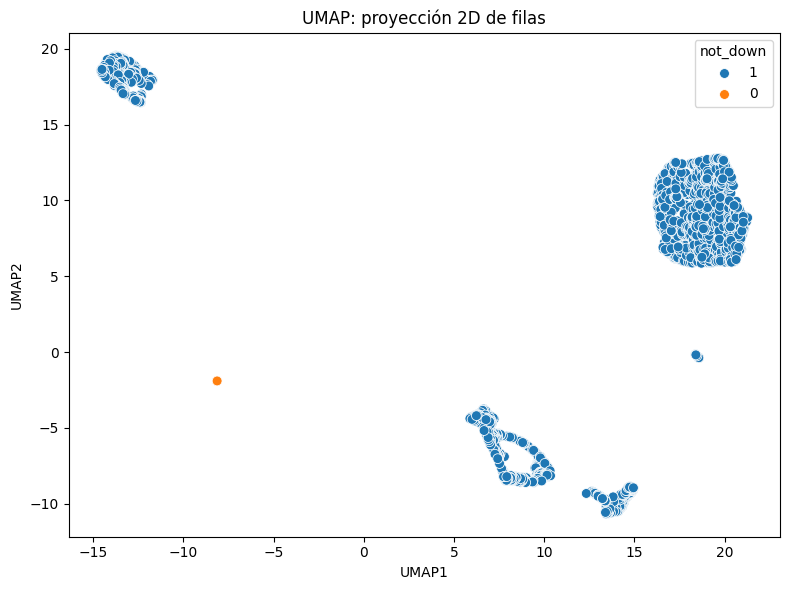

In [8]:
# Convertir cada fila en vector, reducir con UMAP a 2D y graficar
X = df_num.select_dtypes(include=[np.number]).copy()
if X.shape[1] == 0:
    raise ValueError("No hay columnas numéricas en df_num para procesar.")


# Imputar y escalar
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# reducir a 2 dimensiones
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame(embedding, columns=['umap1', 'umap2'], index=X.index)

# graficar; si existe la columna 'not_down' la usamos como color
plt.figure(figsize=(8, 6))
if 'not_down' in df_num.columns:
    sns.scatterplot(data=df_umap, x='umap1', y='umap2', hue=df_num['not_down'].astype(str), palette='tab10', s=50)
    plt.legend(title='not_down')
else:
    plt.scatter(df_umap['umap1'], df_umap['umap2'], s=40, alpha=0.8)
plt.title('UMAP: proyección 2D de filas')
plt.xlabel('UMAP1'); plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()

In [9]:
# Instalar plotly si no está disponible
import plotly.express as px
import plotly.graph_objects as go


# Crear una copia del dataframe con la columna de etiquetas
df_plot = df_umap.copy()
df_plot['not_down'] = df_num['not_down'].astype(str)
df_plot['not_down_name'] = df_num['not_down'].map({0: 'Down', 1: 'Not Down'})

# Crear el gráfico interactivo
fig = px.scatter(
    df_plot, 
    x='umap1', 
    y='umap2',
    color='not_down_name',
    color_discrete_map={'Down': 'red', 'Not Down': 'blue'},
    title='UMAP: Proyección 2D de Filas',
    hover_data=['not_down_name'],  # Datos que se muestran al pasar el cursor
    category_orders={'not_down_name': ['Down', 'Not Down']},
    labels={'not_down_name': 'Estado', 'umap1': 'UMAP1', 'umap2': 'UMAP2'}
)

# Mejorar el diseño del gráfico
fig.update_layout(
    legend_title_text='Estado del Sistema',
    height=600,
    width=800,
    plot_bgcolor='rgba(240, 240, 240, 0.8)',
    updatemenus=[
        # Botones para filtrar los datos
        dict(
            type='buttons',
            direction='down',
            buttons=[
                # Botón para mostrar todos los puntos
                dict(
                    args=[{'visible': [True, True]}],
                    label='Mostrar Todos',
                    method='restyle'
                ),
                # Botón para mostrar solo "Down" (0)
                dict(
                    args=[{'visible': [True, False]}],
                    label='Solo Down (0)',
                    method='restyle'
                ),
                # Botón para mostrar solo "Not Down" (1)
                dict(
                    args=[{'visible': [False, True]}],
                    label='Solo Not Down (1)',
                    method='restyle'
                ),
            ],
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ]
)

# Mejorar los marcadores
fig.update_traces(
    marker=dict(size=8, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

# Añadir cuadrícula y mejorar ejes
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', zeroline=True, zerolinecolor='Gray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray', zeroline=True, zerolinecolor='Gray')

# Mostrar el gráfico interactivo
fig.show()

In [10]:
df_umap["Time"] = df["Time"]
df_umap["not_down"] = df_num["not_down"]

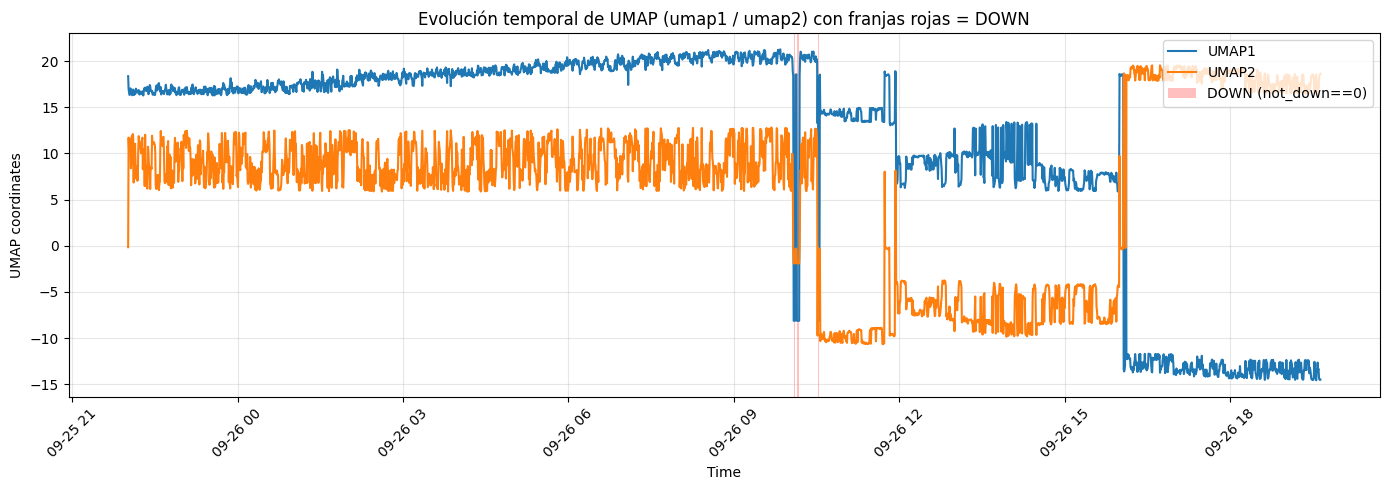

In [11]:
from matplotlib.patches import Patch

# Plot temporal de umap1 / umap2 y franjas rojas cuando el sistema está "down" (not_down == 0)
# Requiere que exista df_umap con columnas: 'umap1', 'umap2', 'Time' y 'not_down'

required = {'umap1', 'umap2', 'Time', 'not_down'}
if not required.issubset(set(df_umap.columns)):
    raise KeyError(f"Faltan columnas en df_umap. Se requieren: {required}")

# asegurarse de tener una columna de tiempo en datetime para el eje x
if not pd.api.types.is_datetime64_any_dtype(df_umap['Time']):
    df_umap = df_umap.copy()
    df_umap['timestamp'] = pd.to_datetime(df_umap['Time'], unit='ms')
else:
    df_umap = df_umap.copy()
    df_umap['timestamp'] = df_umap['Time']

# crear figura
fig, ax = plt.subplots(figsize=(14, 5))

# dibujar líneas
ax.plot(df_umap['timestamp'], df_umap['umap1'], label='UMAP1', color='tab:blue', linewidth=1.5)
ax.plot(df_umap['timestamp'], df_umap['umap2'], label='UMAP2', color='tab:orange', linewidth=1.5)

# identificar intervalos donde not_down == 0 (sistema DOWN)
mask_down = df_umap['not_down'] == 0
if mask_down.any():
    # detectar inicios y finales de bloques contiguos
    starts = df_umap['timestamp'][mask_down & (~mask_down.shift(1, fill_value=False))]
    ends = df_umap['timestamp'][mask_down & (~mask_down.shift(-1, fill_value=False))]
    for s, e in zip(starts.tolist(), ends.tolist()):
        ax.axvspan(s, e, color='red', alpha=0.25, linewidth=0)

# formato del gráfico
ax.set_xlabel('Time')
ax.set_ylabel('UMAP coordinates')
ax.set_title('Evolución temporal de UMAP (umap1 / umap2) con franjas rojas = DOWN')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# añadir leyenda para la franja roja (si hay al menos una)
if mask_down.any():
    ax.legend(handles=[
        plt.Line2D([], [], color='tab:blue', label='UMAP1'),
        plt.Line2D([], [], color='tab:orange', label='UMAP2'),
        Patch(facecolor='red', alpha=0.25, label='DOWN (not_down==0)')
    ], loc='upper right')

plt.show()

Ejecutando T-SNE, puede tomar algo de tiempo...
T-SNE completado en 6.21 segundos


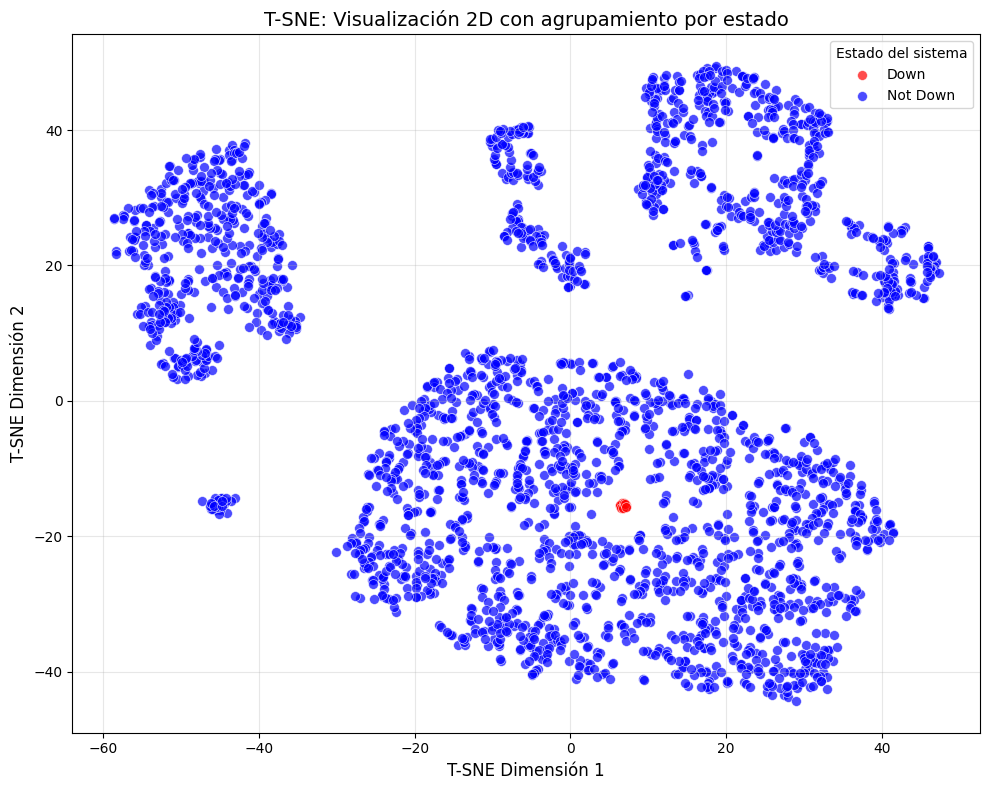

In [12]:
from sklearn.manifold import TSNE
import time

# Usar los mismos datos que en UMAP
X = df_num.select_dtypes(include=[np.number]).copy()
if X.shape[1] == 0:
    raise ValueError("No hay columnas numéricas en df_num para procesar.")

# Imputar y escalar (mismos pasos que para UMAP)
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# Aplicar T-SNE para reducir a 2 dimensiones
print("Ejecutando T-SNE, puede tomar algo de tiempo...")
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedding_tsne = tsne.fit_transform(X_scaled)
print(f"T-SNE completado en {time.time() - start_time:.2f} segundos")

df_tsne = pd.DataFrame(embedding_tsne, columns=['tsne1', 'tsne2'], index=X.index)

# Visualizar con colores según 'not_down' si existe
plt.figure(figsize=(10, 8))
if 'not_down' in df_num.columns:
    # Crear visualización con categorías
    df_plot = df_tsne.copy()
    df_plot['status'] = df_num['not_down'].map({0: 'Down', 1: 'Not Down'})
    
    # Usar diferentes colores por categoría
    colors = {'Down': 'red', 'Not Down': 'blue'}
    
    for status, group in df_plot.groupby('status'):
        plt.scatter(
            group['tsne1'], 
            group['tsne2'], 
            label=status,
            color=colors[status],
            s=50, 
            alpha=0.7,
            edgecolor='w',
            linewidth=0.5
        )
    
    plt.legend(title='Estado del sistema')
    plt.title('T-SNE: Visualización 2D con agrupamiento por estado', fontsize=14)
else:
    plt.scatter(df_tsne['tsne1'], df_tsne['tsne2'], s=40, alpha=0.8)
    plt.title('T-SNE: proyección 2D de filas', fontsize=14)

plt.xlabel('T-SNE Dimensión 1', fontsize=12)
plt.ylabel('T-SNE Dimensión 2', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados del T-SNE en el dataframe para uso posterior
df_tsne["Time"] = df["Time"]
df_tsne["not_down"] = df_num["not_down"]

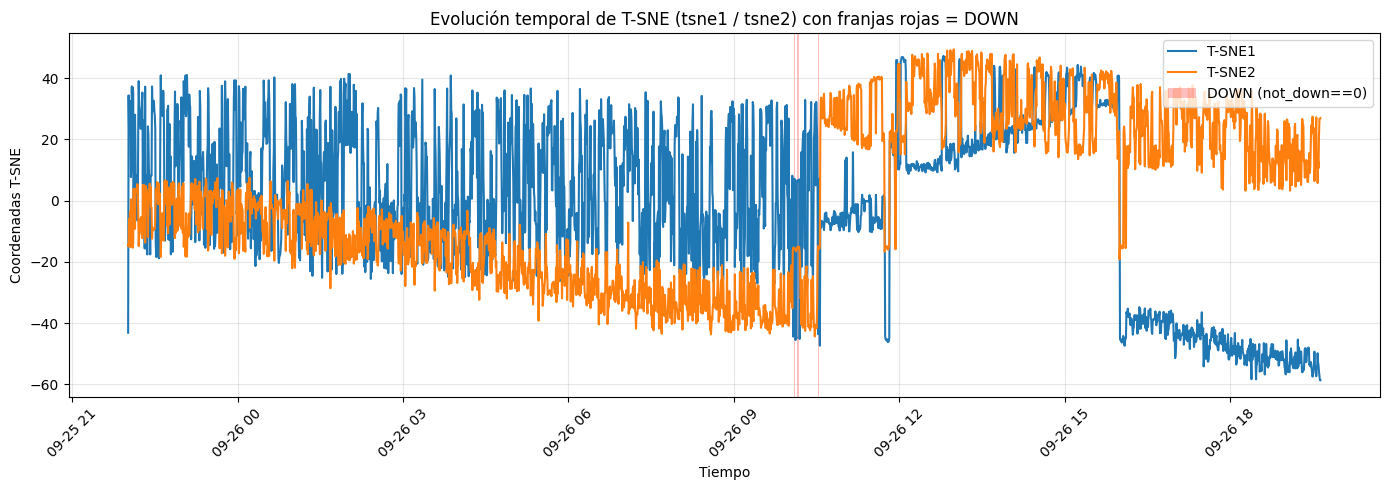

In [13]:
from matplotlib.patches import Patch

# Plot temporal de tsne1 / tsne2 y franjas rojas cuando el sistema está "down" (not_down == 0)
# Requiere que exista df_tsne con columnas: 'tsne1', 'tsne2', 'Time' y 'not_down'

required = {'tsne1', 'tsne2', 'Time', 'not_down'}
if not required.issubset(set(df_tsne.columns)):
    raise KeyError(f"Faltan columnas en df_tsne. Se requieren: {required}")

# Asegurarse de tener una columna de tiempo en datetime para el eje x
if not pd.api.types.is_datetime64_any_dtype(df_tsne['Time']):
    df_tsne = df_tsne.copy()
    df_tsne['timestamp'] = pd.to_datetime(df_tsne['Time'], unit='ms')
else:
    df_tsne = df_tsne.copy()
    df_tsne['timestamp'] = df_tsne['Time']

# Crear figura
fig, ax = plt.subplots(figsize=(14, 5))

# Dibujar líneas para los componentes T-SNE
ax.plot(df_tsne['timestamp'], df_tsne['tsne1'], label='T-SNE1', color='tab:blue', linewidth=1.5)
ax.plot(df_tsne['timestamp'], df_tsne['tsne2'], label='T-SNE2', color='tab:orange', linewidth=1.5)

# Identificar intervalos donde not_down == 0 (sistema DOWN)
mask_down = df_tsne['not_down'] == 0
if mask_down.any():
    # Detectar inicios y finales de bloques contiguos
    starts = df_tsne['timestamp'][mask_down & (~mask_down.shift(1, fill_value=False))]
    ends = df_tsne['timestamp'][mask_down & (~mask_down.shift(-1, fill_value=False))]
    for s, e in zip(starts.tolist(), ends.tolist()):
        ax.axvspan(s, e, color='red', alpha=0.25, linewidth=0)

# Formato del gráfico
ax.set_xlabel('Tiempo')
ax.set_ylabel('Coordenadas T-SNE')
ax.set_title('Evolución temporal de T-SNE (tsne1 / tsne2) con franjas rojas = DOWN')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# Añadir leyenda para la franja roja (si hay al menos una)
if mask_down.any():
    ax.legend(handles=[
        plt.Line2D([], [], color='tab:blue', label='T-SNE1'),
        plt.Line2D([], [], color='tab:orange', label='T-SNE2'),
        Patch(facecolor='red', alpha=0.25, label='DOWN (not_down==0)')
    ], loc='upper right')

plt.show()

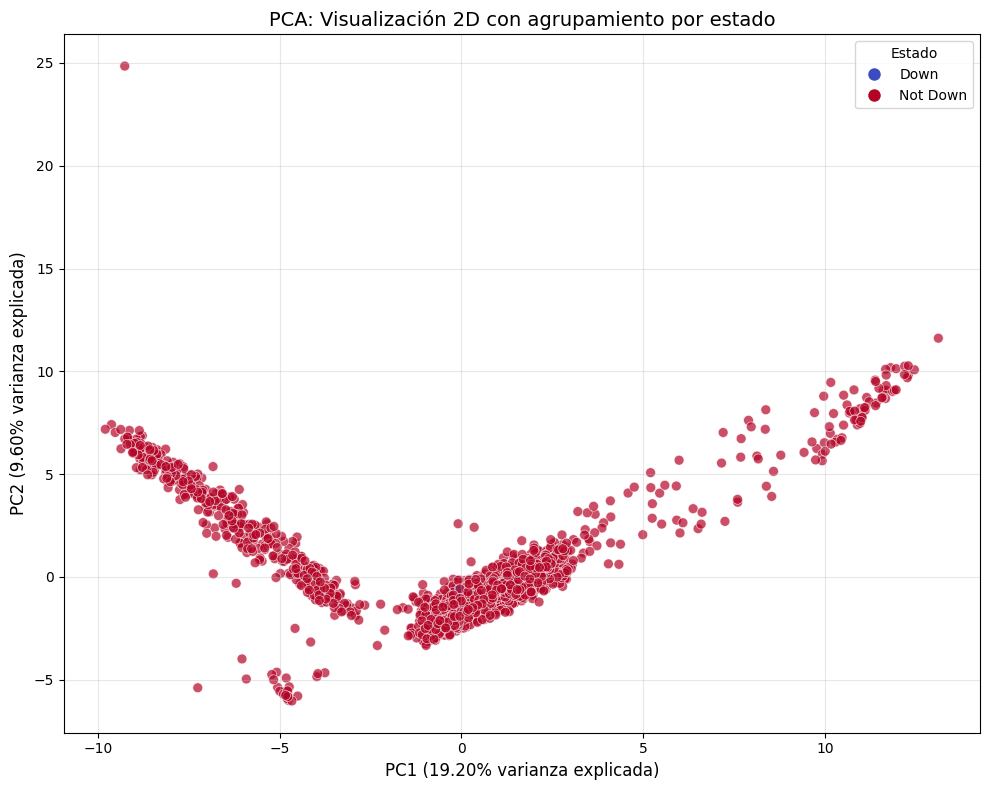

C:\Users\halol\AppData\Local\Temp\ipykernel_6684\699437447.py:90: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\halol\AppData\Local\Temp\ipykernel_6684\699437447.py:97: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




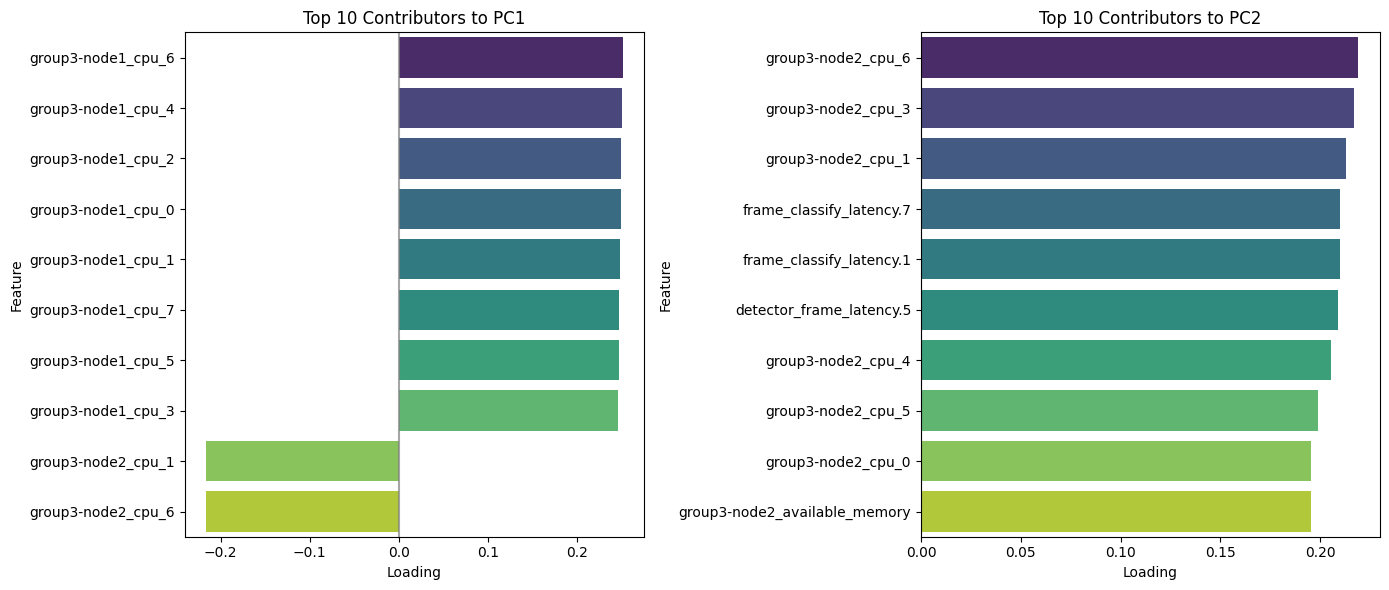

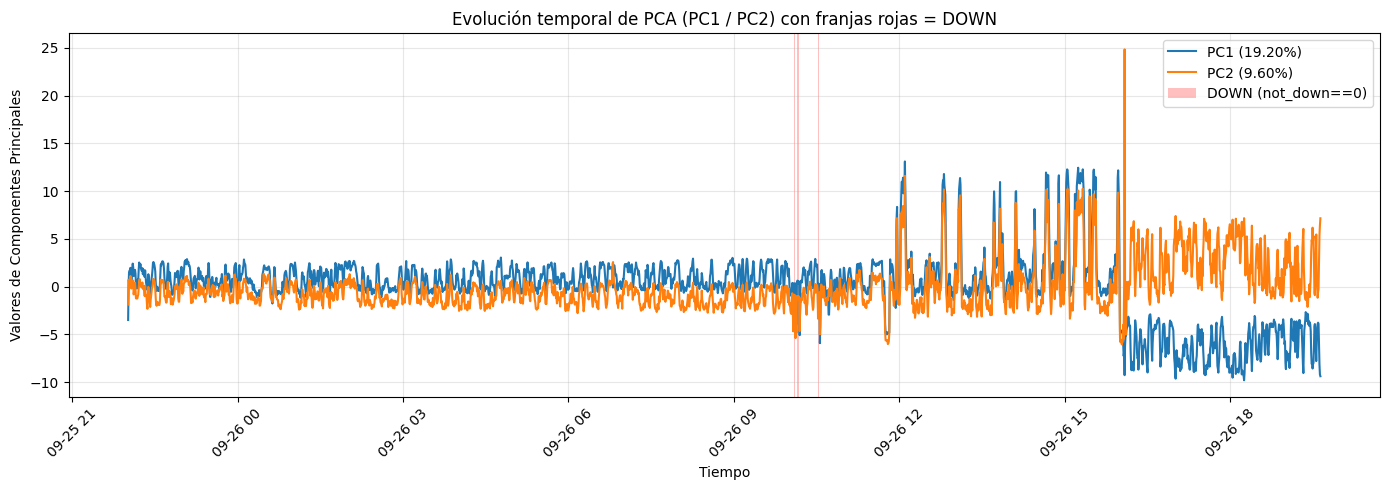

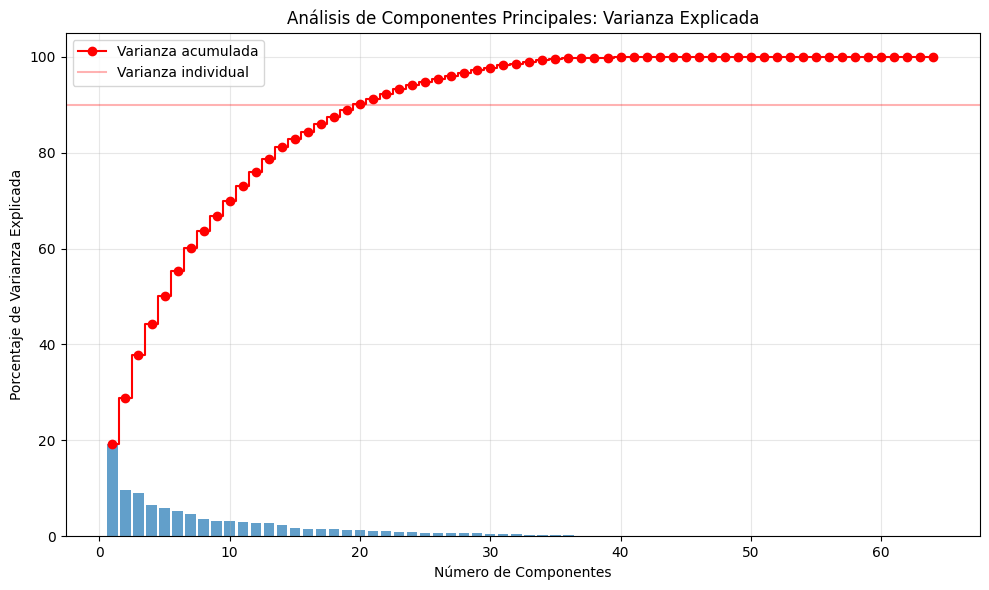

Se necesitan 20 componentes para explicar el 90% de la varianza total.


In [14]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

import matplotlib.pyplot as plt

# Select numeric columns for PCA
X = df_num.select_dtypes(include=[np.number]).copy()
if X.shape[1] == 0:
    raise ValueError("No hay columnas numéricas en df_num para procesar.")

# Impute missing values using median strategy
imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

# Standardize the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(X_scaled)

# Create DataFrame with PCA results
df_pca = pd.DataFrame(embedding_pca, columns=['PC1', 'PC2'], index=X.index)

# Add Time and not_down columns from original data
df_pca['Time'] = df['Time']
df_pca['not_down'] = df_num['not_down']

# Calculate variance explained by each component
explained_variance = pca.explained_variance_ratio_ * 100

# Create 2D scatter plot
plt.figure(figsize=(10, 8))
if 'not_down' in df_num.columns:
    # Create visualization with categories
    scatter = plt.scatter(
        df_pca['PC1'], 
        df_pca['PC2'], 
        c=df_pca['not_down'],
        cmap='coolwarm',
        alpha=0.7,
        s=50,
        edgecolors='w',
        linewidths=0.5
    )
    
    # Add legend with proper labels
    legend_labels = {0: 'Down', 1: 'Not Down'}
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=scatter.cmap(scatter.norm(val)),
                         markersize=10) for val in [0, 1]]
    plt.legend(handles, [legend_labels[val] for val in [0, 1]], title='Estado')
    
    plt.title('PCA: Visualización 2D con agrupamiento por estado', fontsize=14)
else:
    plt.scatter(df_pca['PC1'], df_pca['PC2'], s=40, alpha=0.8)
    plt.title('PCA: proyección 2D de filas', fontsize=14)

plt.xlabel(f'PC1 ({explained_variance[0]:.2f}% varianza explicada)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}% varianza explicada)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Display top contributing features to each principal component
n_features = 10  # Number of top features to display

# Get feature names and their loadings for PC1
pc1_loadings = pd.DataFrame({
    'Feature': X.columns,
    'Loading': pca.components_[0]
})
pc1_loadings = pc1_loadings.reindex(pc1_loadings['Loading'].abs().sort_values(ascending=False).index)

# Get feature names and their loadings for PC2
pc2_loadings = pd.DataFrame({
    'Feature': X.columns,
    'Loading': pca.components_[1]
})
pc2_loadings = pc2_loadings.reindex(pc2_loadings['Loading'].abs().sort_values(ascending=False).index)

# Create subplots for top contributors
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot top contributors to PC1
sns.barplot(x='Loading', y='Feature', data=pc1_loadings.head(n_features), ax=axs[0], palette='viridis')
axs[0].set_title(f'Top {n_features} Contributors to PC1', fontsize=12)
axs[0].set_xlabel('Loading')
axs[0].set_ylabel('Feature')
axs[0].axvline(x=0, color='gray', linestyle='-', alpha=0.7)

# Plot top contributors to PC2
sns.barplot(x='Loading', y='Feature', data=pc2_loadings.head(n_features), ax=axs[1], palette='viridis')
axs[1].set_title(f'Top {n_features} Contributors to PC2', fontsize=12)
axs[1].set_xlabel('Loading')
axs[1].set_ylabel('Feature')
axs[1].axvline(x=0, color='gray', linestyle='-', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot temporal evolution of the principal components
if not pd.api.types.is_datetime64_any_dtype(df_pca['Time']):
    df_pca['timestamp'] = pd.to_datetime(df_pca['Time'], unit='ms')
else:
    df_pca['timestamp'] = df_pca['Time']

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_pca['timestamp'], df_pca['PC1'], label=f'PC1 ({explained_variance[0]:.2f}%)', color='tab:blue', linewidth=1.5)
ax.plot(df_pca['timestamp'], df_pca['PC2'], label=f'PC2 ({explained_variance[1]:.2f}%)', color='tab:orange', linewidth=1.5)

# Identify intervals where not_down == 0 (system DOWN)
mask_down = df_pca['not_down'] == 0
if mask_down.any():
    # Detect beginnings and endings of contiguous blocks
    starts = df_pca['timestamp'][mask_down & (~mask_down.shift(1, fill_value=False))]
    ends = df_pca['timestamp'][mask_down & (~mask_down.shift(-1, fill_value=False))]
    for s, e in zip(starts.tolist(), ends.tolist()):
        ax.axvspan(s, e, color='red', alpha=0.25, linewidth=0)

ax.set_xlabel('Tiempo')
ax.set_ylabel('Valores de Componentes Principales')
ax.set_title('Evolución temporal de PCA (PC1 / PC2) con franjas rojas = DOWN')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

if mask_down.any():
    ax.legend(handles=[
        plt.Line2D([], [], color='tab:blue', label=f'PC1 ({explained_variance[0]:.2f}%)'),
        plt.Line2D([], [], color='tab:orange', label=f'PC2 ({explained_variance[1]:.2f}%)'),
        Patch(facecolor='red', alpha=0.25, label='DOWN (not_down==0)')
    ], loc='upper right')
else:
    ax.legend(loc='upper right')

plt.show()

# Calculate explained variance for all components
pca_full = PCA().fit(X_scaled)
explained_variance_full = pca_full.explained_variance_ratio_ * 100

# Plot scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_full) + 1), explained_variance_full, alpha=0.7)
plt.step(range(1, len(explained_variance_full) + 1), np.cumsum(explained_variance_full), where='mid', color='red', marker='o')
plt.axhline(y=90, color='r', linestyle='-', alpha=0.3)  # Line at 90% explained variance
plt.xlabel('Número de Componentes')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.title('Análisis de Componentes Principales: Varianza Explicada')
plt.legend(['Varianza acumulada', 'Varianza individual'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find components needed for 90% variance
n_components_90 = np.argmax(np.cumsum(explained_variance_full) >= 90) + 1
print(f"Se necesitan {n_components_90} componentes para explicar el 90% de la varianza total.")